# DINA CDE / TOKK Corruption Diagnostics

Loads the 5 diagnostic dumps produced by the instrumented Fortran code, in
their execution-order pipeline:

`MIDC` (geometry: `midc_profiles.dat`) → `DIFMF_1_c` entry / pre-solve
(`cde_entry_profiles.dat`) → `DIFMF_1_c` post-solve
(`cde_profiles.dat`) → `TOKK` (`tokk_profiles.dat`) → `dina_outp_eq`
pre-remap (`raw_profiles.dat`).

Goal: find the **first** stage in this pipeline where `q`/`c2`/`c20`/`tok1`
become oscillatory, to pinpoint the responsible subroutine. See
`DEBUG_CONTEXT.md` for full background.


## Data dictionary: where each dump comes from and what it means

All dumps are one row per grid index `i` (the DINA 1D transport grid,
`a(i)`, `i=1..n`, `i=1` is the magnetic axis, `i=n` is the LCFS), for a
given call. `ai` = normalized minor radius (`~sqrt(psi_N)`), the natural
x-axis for all these plots.

| DataFrame | Fortran source (dump call site) | Written from | Meaning |
|---|---|---|---|
| `midc` | `midc_profiles.dat`, dumped inside `MIDC` (`diter_1.f`) | Flux-surface geometry solve, run every Picard iteration after `ptoke1` | Metric coefficients from the (ρ,θ) flux-surface grid: `c2`,`c3` (used to build `psi`→`q` and the CDE diffusion coefficients), `vi`=dV/da, `s`=surface area factor. Purely geometric — no transport physics yet. |
| `cde_entry` | `cde_entry_profiles.dat`, dumped by `dina_dump_cde_entry` at the very top of `DIFMF_1_c` (`ddunew0.f`), **before** the tridiagonal solve | CDE entry state, i.e. the previous iteration's `dm0` re-derived into `psi`/`q`/`pfi` | Snapshot of the flux state *as the CDE sees it walking in*: `psi=(dm0(i)-dm0(i-1))/ha(i)` (dΨ/da), `q=-pfi/psi`, `pfi=2π·rs0·c3·f` (poloidal current function). Use this to check whether corruption is already present before the CDE solve runs. |
| `cde` | `cde_profiles.dat`, dumped by `dina_dump_cde` at the end of `DIFMF_1_c`, **after** the tridiagonal (`PROGP`) solve | CDE post-solve state | The actual solver output for this `ntay`: new `dm0`, `dmn` (previous-step value used in backward-Euler), `psi`, `q`, plus the CDE's internal current-drive/advective terms `gk`, `dfma`, `dfmax`, `dfmax0`, `fji`, `tok1`. This is the flux-diffusion result later consumed by `ppx_pffx()`. |
| `tokk` | `tokk_profiles.dat`, dumped inside `TOKK` (`diter_1.f`), called from `pff_calc` | Ampère's-law current reconstruction from the *new* `psi` | `c20=-c2·psi` (enclosed current proxy), `tok1`=fitted total `j_tor(a)`, `aak`/`bbk`/`cck` are the local fit coefficients. This is how `FF'` gets its `j_tor`-derived (non-pressure) part. |
| `raw` | `raw_profiles.dat`, dumped in `n_dina_imas33.f` pre-IMAS-remap | The final per-timestep profiles on DINA's native grid, before being interpolated onto the IMAS/IDS output grid | `ppx`/`pffx` = the actual `p'(a)`/`FF'(a)` tables that `ptoke1`/`cur_dens` will consume on the *next* timestep (built by `ppx_pffx()` from `cde`'s `pp`/`pff`). `tok1` here = `j_tor` on the raw grid, `q`/`f` for reference. |
| `bc` | `tpl_cal_bc.log`, dumped inside `tpl_cal_c` (`ndop1_new2_400.f`), one row per call (i.e. per `ntay`) | The Robin boundary-condition state for the CDE, computed just before `DIFMF_1` is called | `pll`/`pll0`, `tpl`/`tpl0`, `fdd`/`fdd0` = current loop-voltage/flux history terms; `udd` = derived surface loop voltage; `UDM`,`ZDM` = the actual Robin BC coefficients fed into `PROGP` (`ZDM=UDM·(-DMN(n)+pll0·tpl0+udd·tay·100)`); `mismatch=pll0·tpl0-DMN(n)` is the quantity whose imbalance drives the BC. |

**Pipeline order per timestep**: `MIDC` (geometry) → `tpl_cal_c` writes
`bc` row, computes Robin BC, calls `DIFMF_1_c` → `cde_entry` dumped →
tridiagonal solve → `cde` dumped → `pp_calc`/`pff_calc` → `TOKK` (`tokk`
dumped) → `ppx_pffx()` remaps `cde`'s `pp`/`pff` onto the standard
grid → `raw` (next timestep's `ppx`/`pffx` tables) → fed back into
`ptoke1`/`cur_dens` for the next Picard/timestep iteration.


In [36]:
%matplotlib inline
import numpy as np
import pandas as pd
path_to_file = '~/scratch/'
raw = pd.read_csv(path_to_file + 'raw_profiles.dat', sep=r'\s+', skiprows=1,
                   names=['tt','i','a','ai','dm0','p','ppx','pffx',
                          'tok1','q','f'])
tokk = pd.read_csv(path_to_file + 'tokk_profiles.dat', sep=r'\s+', skiprows=1,
                    names=['tt','i','a','ai','psi','c2','c20','aak',
                           'bbk','cck','s','tok1'])
cde = pd.read_csv(path_to_file + 'cde_profiles.dat', sep=r'\s+', skiprows=1,
                   names=['tt','ntay','i','ai','a','dm0','dmn','psi','q',
                          'gk','dfma','dfmax','dfmax0','fji','tok1','f',
                          'ptor'])
cde_entry = pd.read_csv(path_to_file + 'cde_entry_profiles.dat', sep=r'\s+',
                         skiprows=1,
                         names=['tt','ntay','i','ai','a','dm0','psi','q',
                                'pfi','c3','f','ha'])
midc = pd.read_csv(path_to_file + 'midc_profiles.dat', sep=r'\s+', skiprows=1,
                    names=['tt','i','a','ai','ha','c2','c3','vi','s','f'])

# Pick the last / crash timestep
# time_to_fetch = raw['tt'].min()
tmp = cde_entry[cde_entry['ntay'] == 4]
time_to_fetch = tmp['tt'].max()
r = raw[raw.tt == time_to_fetch]
t = tokk[tokk.tt == time_to_fetch]
c = cde[cde.tt == time_to_fetch]
ce = cde_entry[cde_entry.tt == time_to_fetch]
m = midc[midc.tt == time_to_fetch]


In [37]:
import matplotlib.pyplot as plt

# --- Overview: which timesteps/ntay are present in each dump? ---
print('raw_profiles.dat        tt range:', raw.tt.min(), '->', raw.tt.max(),
      '| n timesteps:', raw.tt.nunique())
print('tokk_profiles.dat       tt range:', tokk.tt.min(), '->', tokk.tt.max(),
      '| n timesteps:', tokk.tt.nunique())
print('cde_profiles.dat        tt range:', cde.tt.min(), '->', cde.tt.max(),
      '| n timesteps:', cde.tt.nunique(),
      '| ntay range:', cde.ntay.min(), '->', cde.ntay.max())
print('cde_entry_profiles.dat  tt range:', cde_entry.tt.min(), '->',
      cde_entry.tt.max(), '| n timesteps:', cde_entry.tt.nunique(),
      '| ntay range:', cde_entry.ntay.min(), '->', cde_entry.ntay.max())
print('midc_profiles.dat       tt range:', midc.tt.min(), '->', midc.tt.max(),
      '| n timesteps:', midc.tt.nunique())

# Sorted list of distinct ntay values actually present in the CDE dumps
# (useful to confirm/deny whether ntay=0 is genuinely absent from the run,
# vs. just not dumped).
print('\nDistinct ntay values in cde_profiles.dat (first 10):',
      sorted(cde.ntay.unique())[:10])
print('Distinct ntay values in cde_entry_profiles.dat (first 10):',
      sorted(cde_entry.ntay.unique())[:10])


raw_profiles.dat        tt range: 39001.0 -> 39003.0 | n timesteps: 3
tokk_profiles.dat       tt range: 39000.0 -> 39003.0 | n timesteps: 4
cde_profiles.dat        tt range: 0.0 -> 39003.0 | n timesteps: 6 | ntay range: 0.0 -> 3.0
cde_entry_profiles.dat  tt range: 39000.0 -> 39003.0 | n timesteps: 4 | ntay range: 0 -> 3
midc_profiles.dat       tt range: 39000.0 -> 39003.0 | n timesteps: 4

Distinct ntay values in cde_profiles.dat (first 10): [0.0, nan, 1.0, 2.0, 3.0]
Distinct ntay values in cde_entry_profiles.dat (first 10): [0, 1, 2, 3]


In [38]:
# --- Crash-adjacent snapshot: pin ALL dumps to the same physical time.
# We take the last tt in cde_entry (typically the crash step or the last
# completed step), propagate that tt to raw/tokk/midc, and derive the
# corresponding ntay for cde/cde_entry selection. This guarantees every
# per-timestep panel below compares quantities at the SAME simulation
# time, not a mix of an early ntay against a late tt.
time_to_fetch = cde_entry['tt'].max()

# ntay corresponding to that tt (each ntay writes n rows of cde_entry
# at a single tt, so pick any row and read its ntay)
ntay_to_fetch = int(
    cde_entry.loc[cde_entry['tt'] == time_to_fetch, 'ntay'].iloc[0]
)

r  = raw[raw.tt == time_to_fetch]
t  = tokk[tokk.tt == time_to_fetch]
c  = cde[cde.ntay == ntay_to_fetch]
ce = cde_entry[cde_entry.ntay == ntay_to_fetch]
m  = midc[midc.tt == time_to_fetch]

print('Crash-adjacent snapshot: tt =', time_to_fetch,
      '| ntay =', ntay_to_fetch)
print('rows: raw=%d tokk=%d cde=%d cde_entry=%d midc=%d'
      % (len(r), len(t), len(c), len(ce), len(m)))


Crash-adjacent snapshot: tt = 39003.0 | ntay = 3
rows: raw=50 tokk=200 cde=200 cde_entry=200 midc=800


**Grid sanity check.** `a`/`ai` = DINA's 1D transport grid coordinate and its normalized (`ai=sqrt(psi_N)`-like) counterpart, as seen independently in `raw`, `tokk`, and `cde` — just confirming all three dumps share the same underlying grid indexing before comparing values across them.

**Source: `raw` (`raw_profiles.dat`).** These are the final per-timestep `p'`/`FF'`/`j_tor`/`q`/`f` tables on DINA's native grid, i.e. what actually gets fed back into `ptoke1`/`cur_dens` for the *next* Picard/timestep — the end product of the whole CDE→`ppx_pffx`→GS pipeline for this step.

**Sources: `cde` (post-solve `dm0`/`q`) and `tokk` (`c20`/`tok1`).** `c20=-c2·psi` is TOKK's Ampère-law input built from the CDE's new `psi`; `tok1` is TOKK's fitted total `j_tor(a)` output. Comparing `c20` (input) vs `tok1` (output) shows what TOKK does to the CDE's raw current signal.

**Full pipeline snapshot, one timestep.** Top row = `midc` geometry (`c2`,`c3`,`s`,`vi`), computed once per Picard iteration, upstream of everything else. Bottom row = `cde_entry` (pre-solve `q`/`psi`, i.e. last step's state) vs `cde` (post-solve, this step's new `q`/`psi`/`dm0`), plus `tokk`'s `c20`→`tok1`. Reading left-to-right, top-to-bottom roughly follows the actual call order.

**"Roughness" trend across ALL timesteps.** `roughness(df, col)` = std of the discrete 2nd derivative of `col` along the grid, per timestep — a smooth profile gives a small value, a jagged/oscillatory one a large value. Applied to `midc.c2` (geometry), `cde_entry.q`/`cde.q` (pre/post-solve), `tokk.c20`/`tokk.tok1`, to see which stage first develops oscillation as a function of time, independent of any single-timestep snapshot.

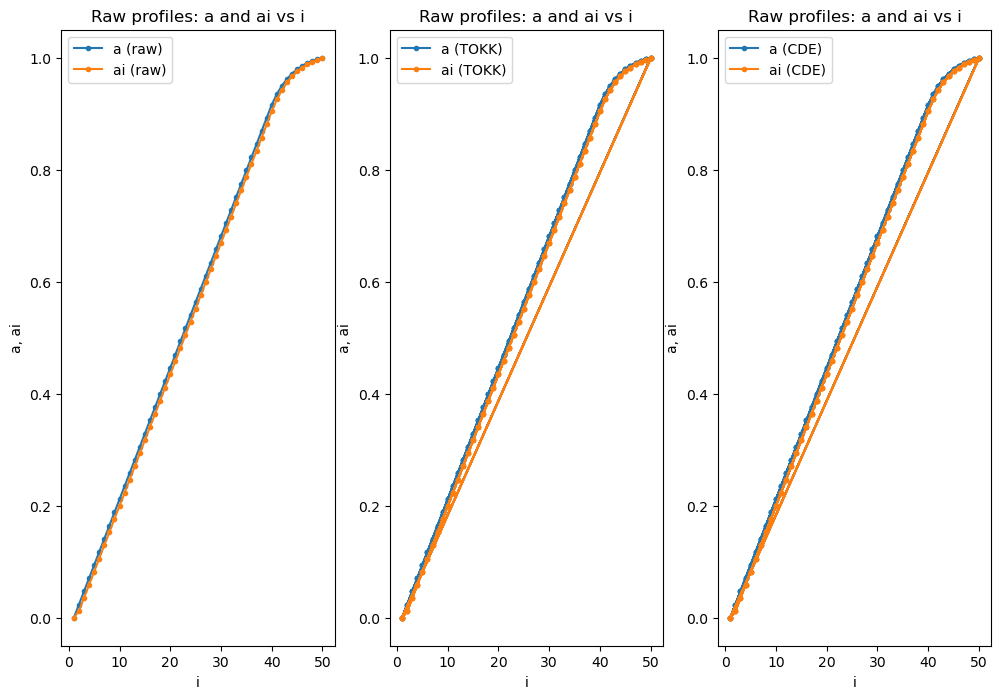

In [39]:

import matplotlib.pyplot as plt
fig0, ax0 = plt.subplots(1,3, figsize=(12, 8))
# ax0 is a 1D array with 3 Axes (since nrows=1, ncols=3)
# Raw
ax0[0].plot(r.i, r.a, '.-', label='a (raw)')
ax0[0].plot(r.i, r.ai, '.-', label='ai (raw)')
ax0[0].set_title('Raw profiles: a and ai vs i')
ax0[0].set_xlabel('i')
ax0[0].set_ylabel('a, ai')
ax0[0].legend()
# TOKK
ax0[1].plot(t.i, t.a, '.-', label='a (TOKK)')
ax0[1].plot(t.i, t.ai, '.-', label='ai (TOKK)')
ax0[1].set_title('Raw profiles: a and ai vs i')
ax0[1].set_xlabel('i')
ax0[1].set_ylabel('a, ai')
ax0[1].legend()
# CDE 
ax0[2].plot(c.i, c.a, '.-', label='a (CDE)')
ax0[2].plot(c.i, c.ai, '.-', label='ai (CDE)')
ax0[2].set_title('Raw profiles: a and ai vs i')
ax0[2].set_xlabel('i')
ax0[2].set_ylabel('a, ai')
ax0[2].legend()



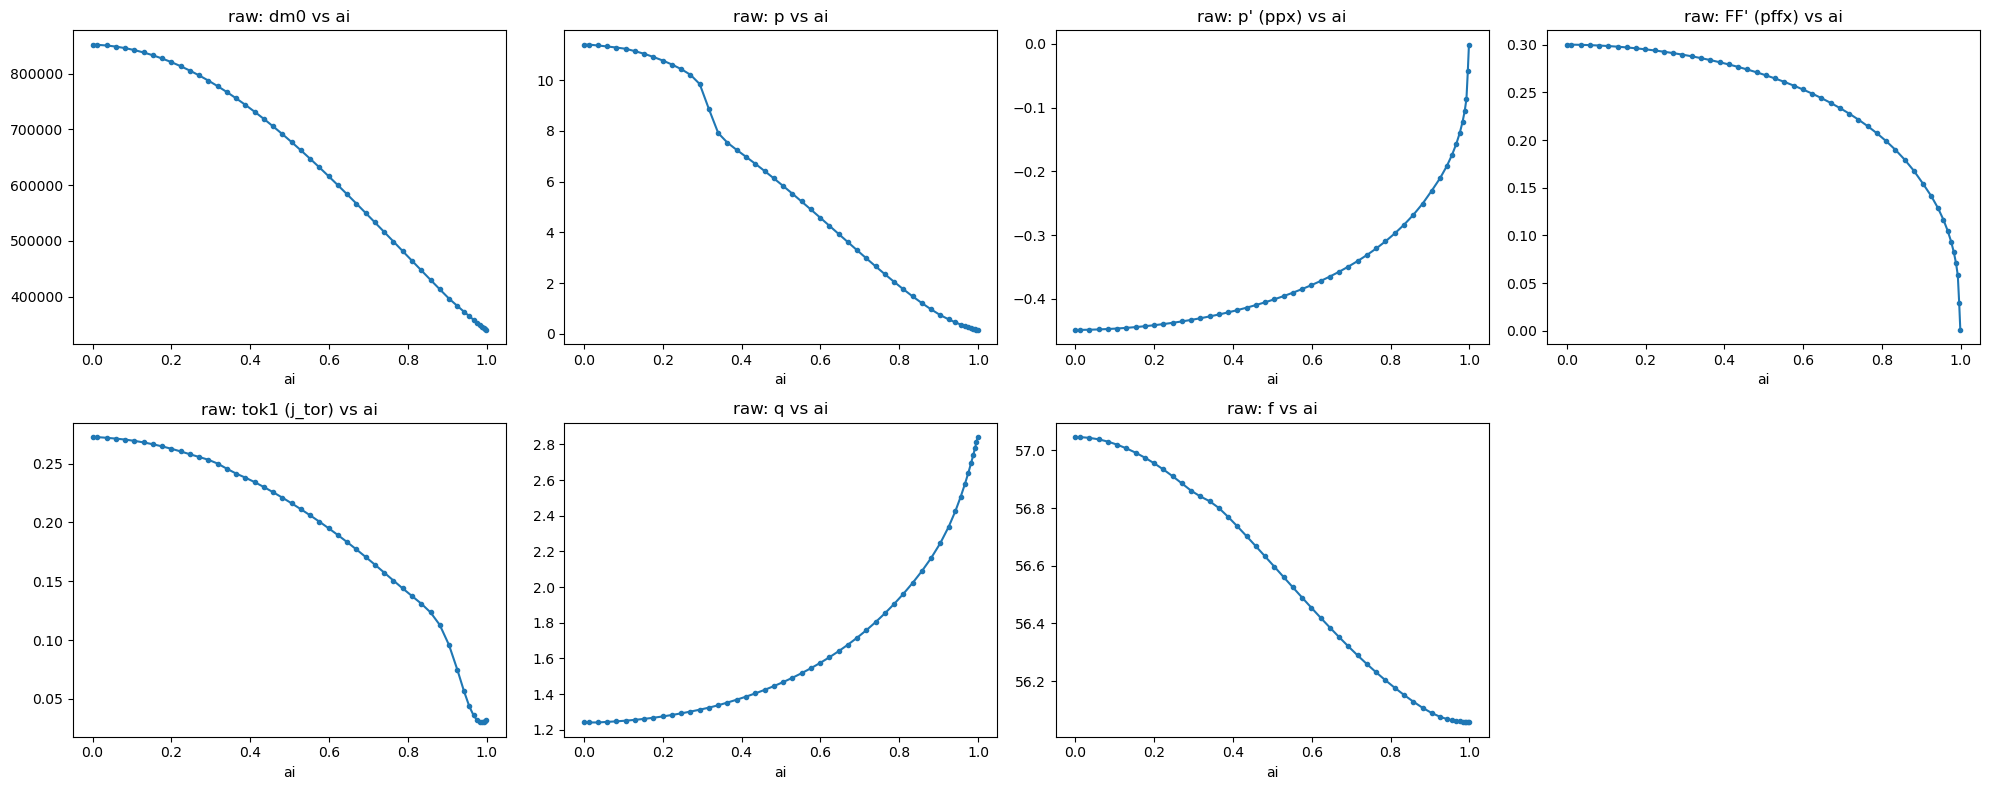

In [40]:
# --- Full raw_profiles.dat overview (pre-IMAS-remap, native DINA grid) ---
fig_raw, axr = plt.subplots(2, 4, figsize=(20, 8))

axr[0,0].plot(r.ai, r.dm0, '.-');   axr[0,0].set_title('raw: dm0 vs ai')
axr[0,1].plot(r.ai, r.p, '.-');     axr[0,1].set_title('raw: p vs ai')
axr[0,2].plot(r.ai, r.ppx, '.-');   axr[0,2].set_title("raw: p' (ppx) vs ai")
axr[0,3].plot(r.ai, r.pffx, '.-');  axr[0,3].set_title("raw: FF' (pffx) vs ai")

axr[1,0].plot(r.ai, r.tok1, '.-');  axr[1,0].set_title('raw: tok1 (j_tor) vs ai')
axr[1,1].plot(r.ai, r.q, '.-');     axr[1,1].set_title('raw: q vs ai')
axr[1,2].plot(r.ai, r.f, '.-');     axr[1,2].set_title('raw: f vs ai')
axr[1,3].axis('off')

for ax in axr.flat:
    ax.set_xlabel('ai')

plt.tight_layout(); plt.show()


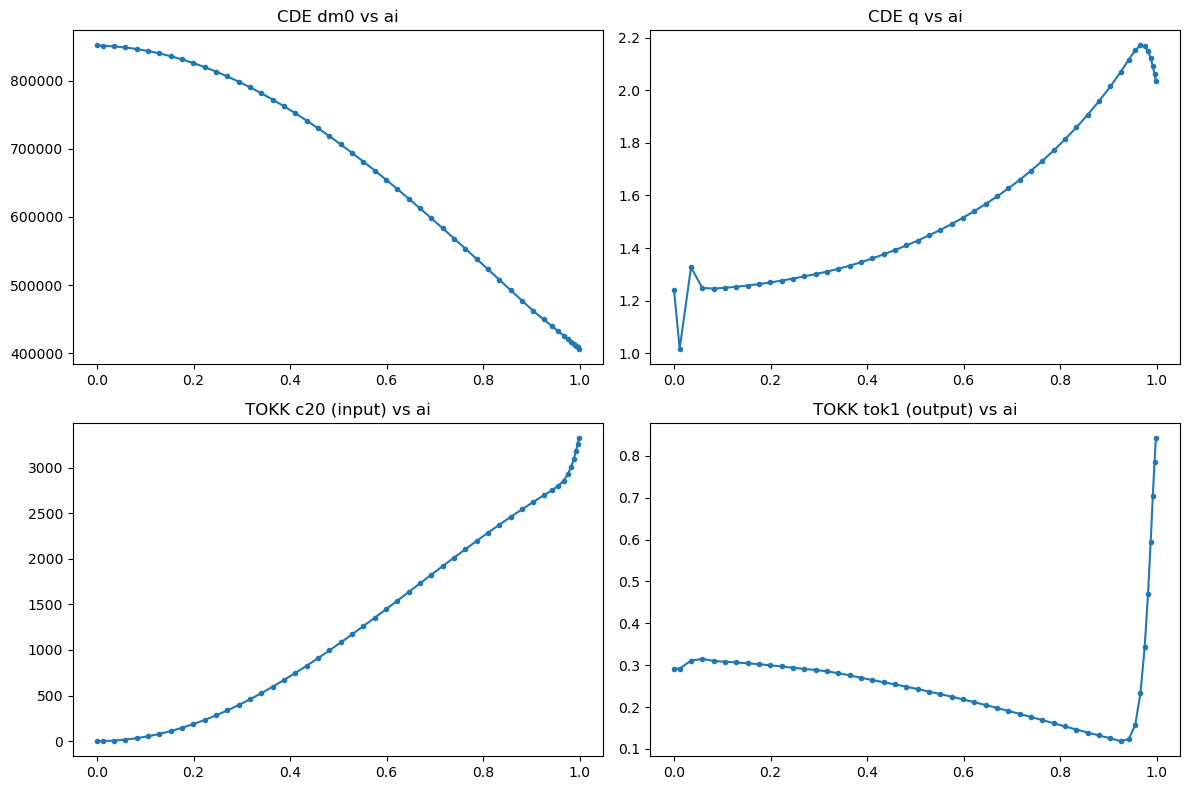

In [41]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
axs[0,0].plot(c.ai[0:50], c.dm0[0:50], '.-'); axs[0,0].set_title('CDE dm0 vs ai')
axs[0,1].plot(c.ai[0:50], c.q[0:50], '.-');   axs[0,1].set_title('CDE q vs ai')
axs[1,0].plot(t.ai[0:50], t.c20[0:50], '.-'); axs[1,0].set_title('TOKK c20 (input) vs ai')
axs[1,1].plot(t.ai[0:50], t.tok1[0:50], '.-');axs[1,1].set_title('TOKK tok1 (output) vs ai')
plt.tight_layout(); plt.show()



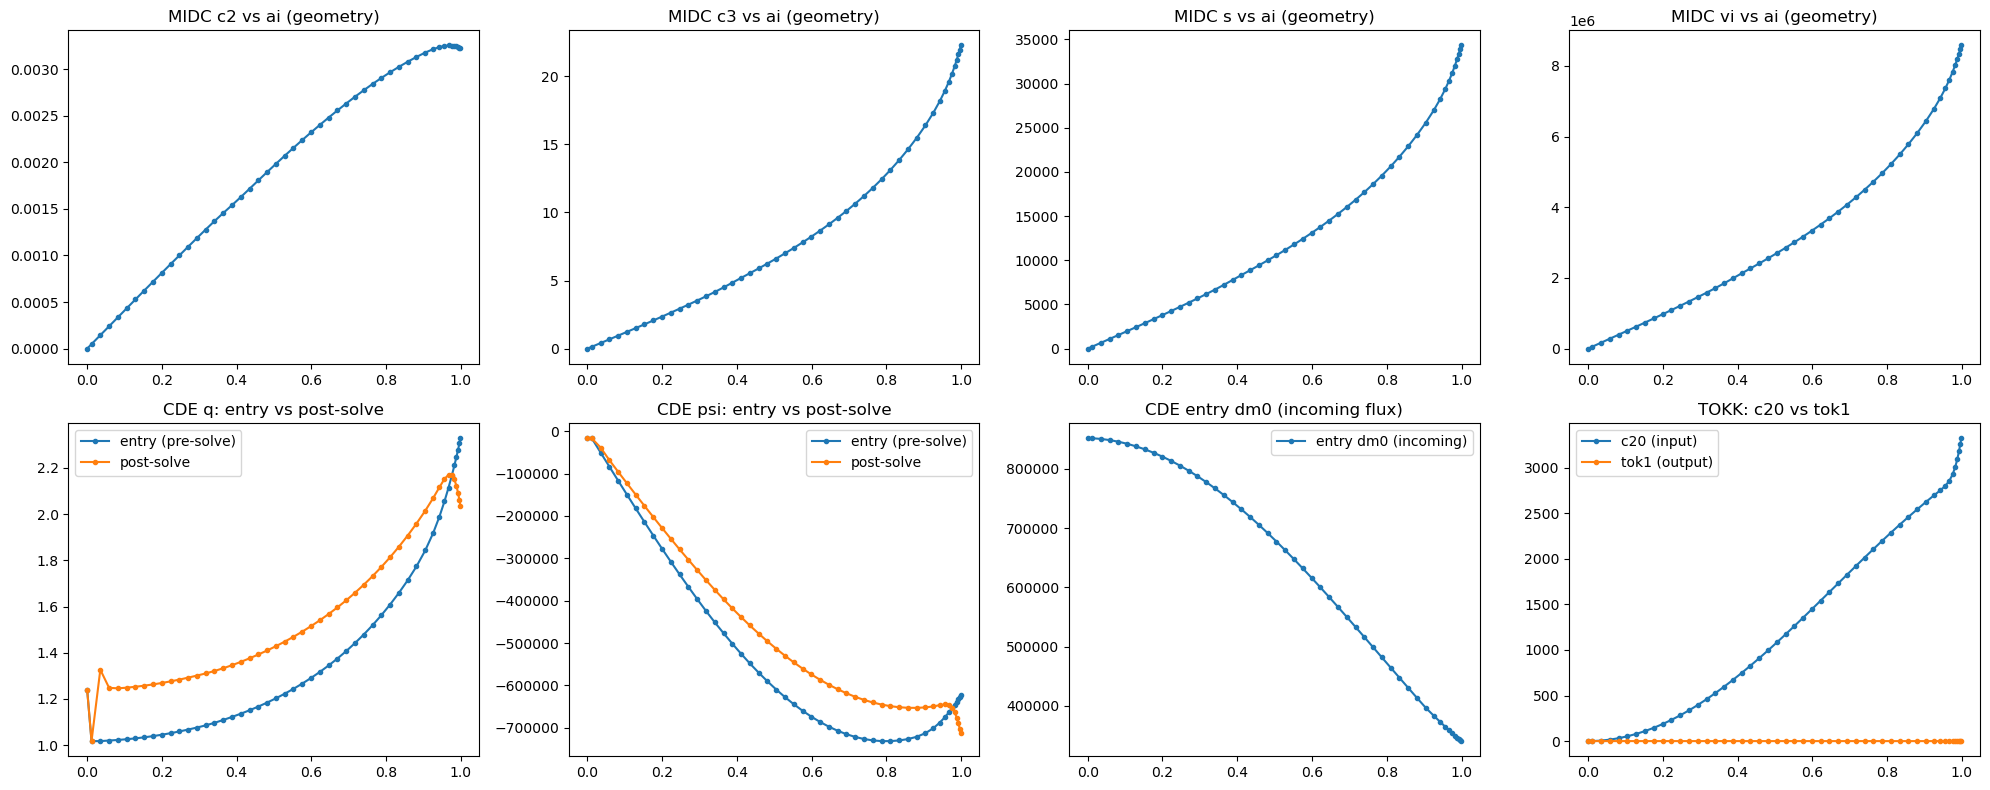

In [42]:
fig2, axs2 = plt.subplots(2, 4, figsize=(20, 8))

# Stage 1: MIDC geometry (feeds both TOKK and CDE)
axs2[0,0].plot(m.ai[0:50], m.c2[0:50], '.-'); axs2[0,0].set_title('MIDC c2 vs ai (geometry)')
axs2[0,1].plot(m.ai[0:50], m.c3[0:50], '.-'); axs2[0,1].set_title('MIDC c3 vs ai (geometry)')
axs2[0,2].plot(m.ai[0:50], m.s[0:50], '.-');  axs2[0,2].set_title('MIDC s vs ai (geometry)')
axs2[0,3].plot(m.ai[0:50], m.vi[0:50], '.-'); axs2[0,3].set_title('MIDC vi vs ai (geometry)')

# Stage 2/3: CDE entry (pre-solve) vs CDE post-solve q/psi
axs2[1,0].plot(ce.ai[0:50], ce.q[0:50], '.-', label='entry (pre-solve)')
axs2[1,0].plot(c.ai[0:50], c.q[0:50], '.-', label='post-solve')
axs2[1,0].set_title('CDE q: entry vs post-solve'); axs2[1,0].legend()

axs2[1,1].plot(ce.ai[0:50], ce.psi[0:50], '.-', label='entry (pre-solve)')
axs2[1,1].plot(c.ai[0:50], c.psi[0:50], '.-', label='post-solve')
axs2[1,1].set_title('CDE psi: entry vs post-solve'); axs2[1,1].legend()

axs2[1,2].plot(ce.ai[0:50], ce.dm0[0:50], '.-', label='entry dm0 (incoming)')
axs2[1,2].set_title('CDE entry dm0 (incoming flux)'); axs2[1,2].legend()

# Stage 4: TOKK output (downstream of both MIDC and CDE)
axs2[1,3].plot(t.ai[0:50], t.c20[0:50], '.-', label='c20 (input)')
axs2[1,3].plot(t.ai[0:50], t.tok1[0:50], '.-', label='tok1 (output)')
axs2[1,3].set_title('TOKK: c20 vs tok1'); axs2[1,3].legend()

plt.tight_layout(); plt.show()


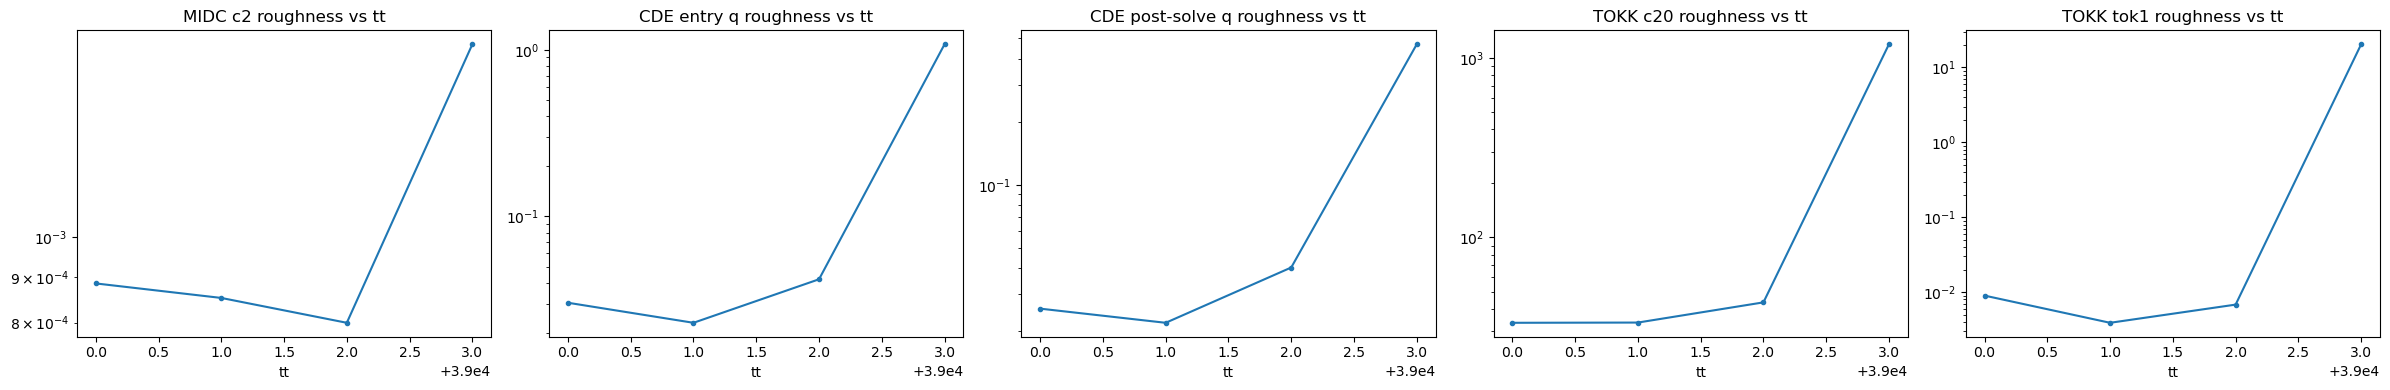

First 10 timesteps: CDE-entry q roughness (pre-solve, native ai grid):
        tt  q_roughness
0  39000.0     0.030374
1  39001.0     0.023028
2  39002.0     0.042004
3  39003.0     1.078865

First 10 timesteps: MIDC c2 roughness (geometry):
        tt  c2_roughness
0  39000.0      0.000886
1  39001.0      0.000853
2  39002.0      0.000800
3  39003.0      0.001649


In [43]:
# --- Oscillation / roughness trend vs time across ALL timesteps ---
# Roughness proxy: std of the discrete 2nd derivative along the profile.
# A smooth profile -> small value; an oscillatory/corrupted profile -> large value.
def roughness(df, col, group_col='tt'):
    out = []
    for key, g in df.sort_values('i').groupby(group_col):
        v = g[col].to_numpy()
        if len(v) < 3:
            continue
        d2 = np.diff(v, n=2)
        out.append((key, np.std(d2)))
    return pd.DataFrame(out, columns=[group_col, col + '_roughness'])

rough_midc_c2   = roughness(midc, 'c2')
rough_cde_q     = roughness(cde, 'q')
rough_cdee_q    = roughness(cde_entry, 'q')
rough_tokk_c20  = roughness(tokk, 'c20')
rough_tokk_tok1 = roughness(tokk, 'tok1')

fig3, axs3 = plt.subplots(1, 5, figsize=(24, 4), sharex=False)
axs3[0].plot(rough_midc_c2.tt, rough_midc_c2.c2_roughness, '.-')
axs3[0].set_title('MIDC c2 roughness vs tt'); axs3[0].set_xlabel('tt')

axs3[1].plot(rough_cdee_q.tt, rough_cdee_q.q_roughness, '.-')
axs3[1].set_title('CDE entry q roughness vs tt'); axs3[1].set_xlabel('tt')

axs3[2].plot(rough_cde_q.tt, rough_cde_q.q_roughness, '.-')
axs3[2].set_title('CDE post-solve q roughness vs tt'); axs3[2].set_xlabel('tt')

axs3[3].plot(rough_tokk_c20.tt, rough_tokk_c20.c20_roughness, '.-')
axs3[3].set_title('TOKK c20 roughness vs tt'); axs3[3].set_xlabel('tt')

axs3[4].plot(rough_tokk_tok1.tt, rough_tokk_tok1.tok1_roughness, '.-')
axs3[4].set_title('TOKK tok1 roughness vs tt'); axs3[4].set_xlabel('tt')

for ax in axs3:
    ax.set_yscale('log')

plt.tight_layout(); plt.show()

# Also print roughness at the very first few timesteps (ntay=1,2,3...) to see
# exactly when/how fast corruption appears/grows.
print('First 10 timesteps: CDE-entry q roughness (pre-solve, native ai grid):')
print(rough_cdee_q.head(10))
print('\nFirst 10 timesteps: MIDC c2 roughness (geometry):')
print(rough_midc_c2.head(10))


**Hypothesis test, source: `cde_entry`.** Testing whether irregular grid
spacing (`ha`) amplifying finite-difference noise in
`psi=(dm0_i-dm0_{i-1})/ha_i` — rather than a genuine physical
oscillation — could explain the near-axis `q`/`psi` noise, by comparing
`ha`, `diff(dm0)` and `psi` side by side, then chasing the same question
down into `pfi`/`f`/`c3` (the other ingredients of `q=-pfi/psi`).

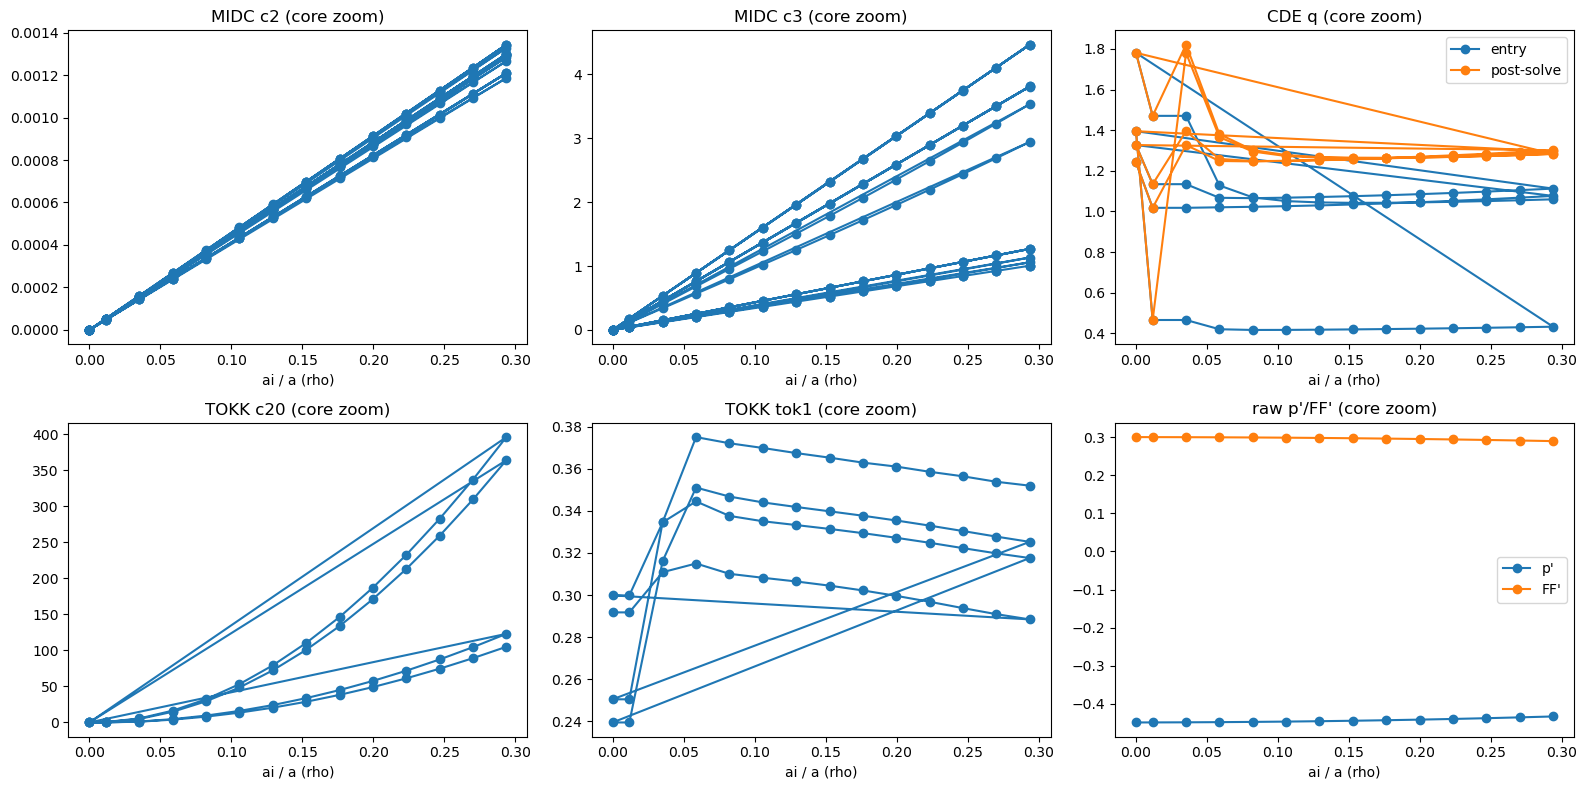

In [44]:
# --- Zoom into the core region (rho ~ 0.05-0.2) where oscillation was
# visually observed in p'/FF'/j_tor plots, across the whole pipeline ---
rho_lo, rho_hi = 0.0, 0.3

def zoom(df, xcol='ai'):
    return df[(df[xcol] >= rho_lo) & (df[xcol] <= rho_hi)]

m_z  = zoom(m)
ce_z = zoom(ce)
c_z  = zoom(c)
t_z  = zoom(t)
r_z  = zoom(r, xcol='ai')

fig4, axs4 = plt.subplots(2, 3, figsize=(16, 8))

axs4[0,0].plot(m_z.ai, m_z.c2, 'o-');  axs4[0,0].set_title('MIDC c2 (core zoom)')
axs4[0,1].plot(m_z.ai, m_z.c3, 'o-');  axs4[0,1].set_title('MIDC c3 (core zoom)')
axs4[0,2].plot(ce_z.ai, ce_z.q, 'o-', label='entry')
axs4[0,2].plot(c_z.ai, c_z.q, 'o-', label='post-solve')
axs4[0,2].set_title('CDE q (core zoom)'); axs4[0,2].legend()

axs4[1,0].plot(t_z.ai, t_z.c20, 'o-');  axs4[1,0].set_title('TOKK c20 (core zoom)')
axs4[1,1].plot(t_z.ai, t_z.tok1, 'o-'); axs4[1,1].set_title('TOKK tok1 (core zoom)')
axs4[1,2].plot(r_z.ai, r_z.ppx, 'o-', label="p'")
axs4[1,2].plot(r_z.ai, r_z.pffx, 'o-', label="FF'")
axs4[1,2].set_title("raw p'/FF' (core zoom)"); axs4[1,2].legend()

for ax in axs4.flat:
    ax.set_xlabel('ai / a (rho)')

plt.tight_layout(); plt.show()


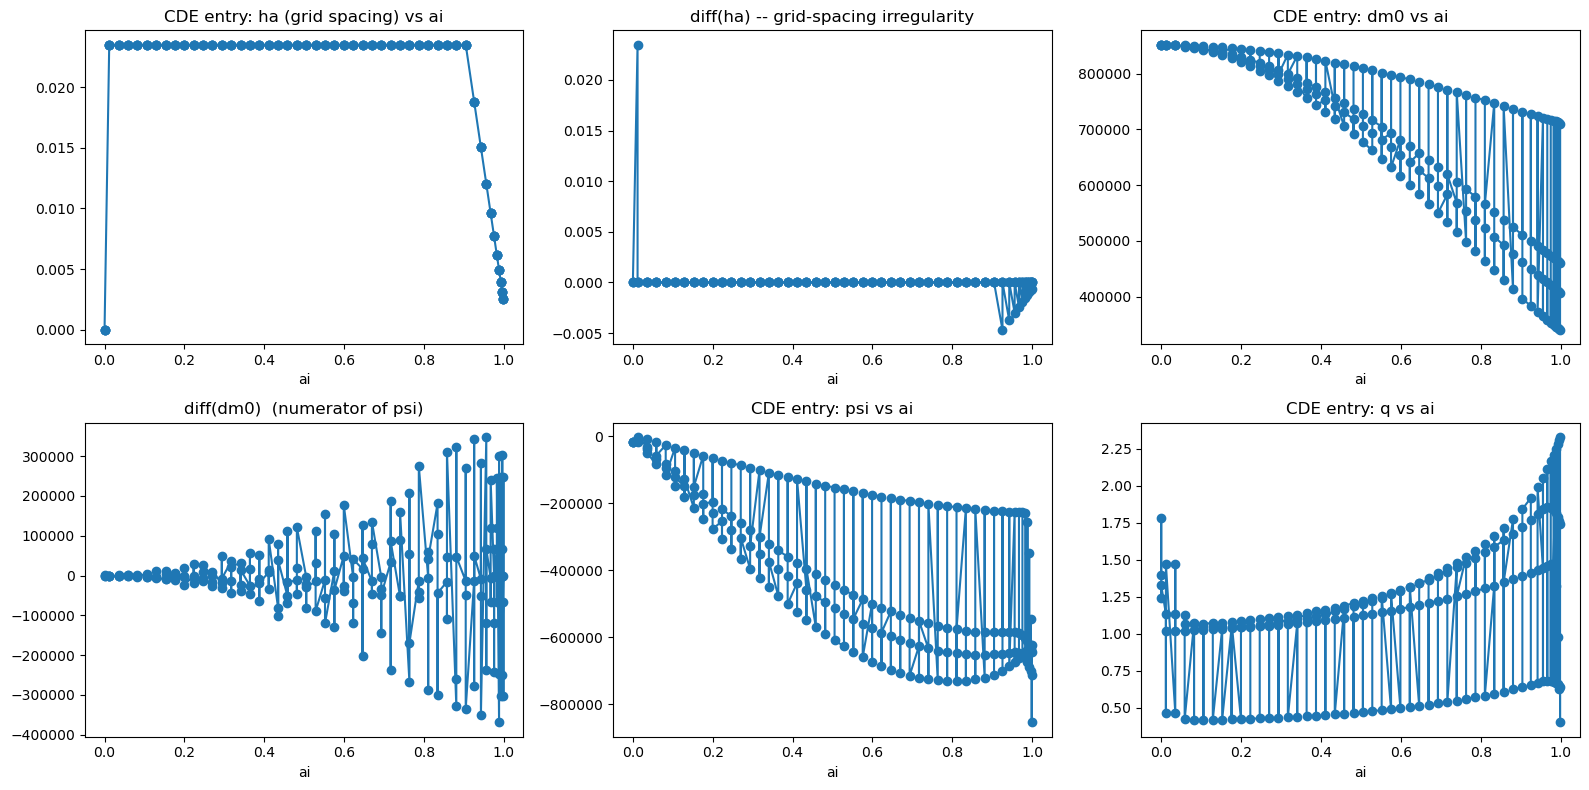

ha stats: min=0 max=0.02349 mean=0.02 std=0.007074
diff(ha) stats: min=-0.004698 max=0.02349 std=0.001754


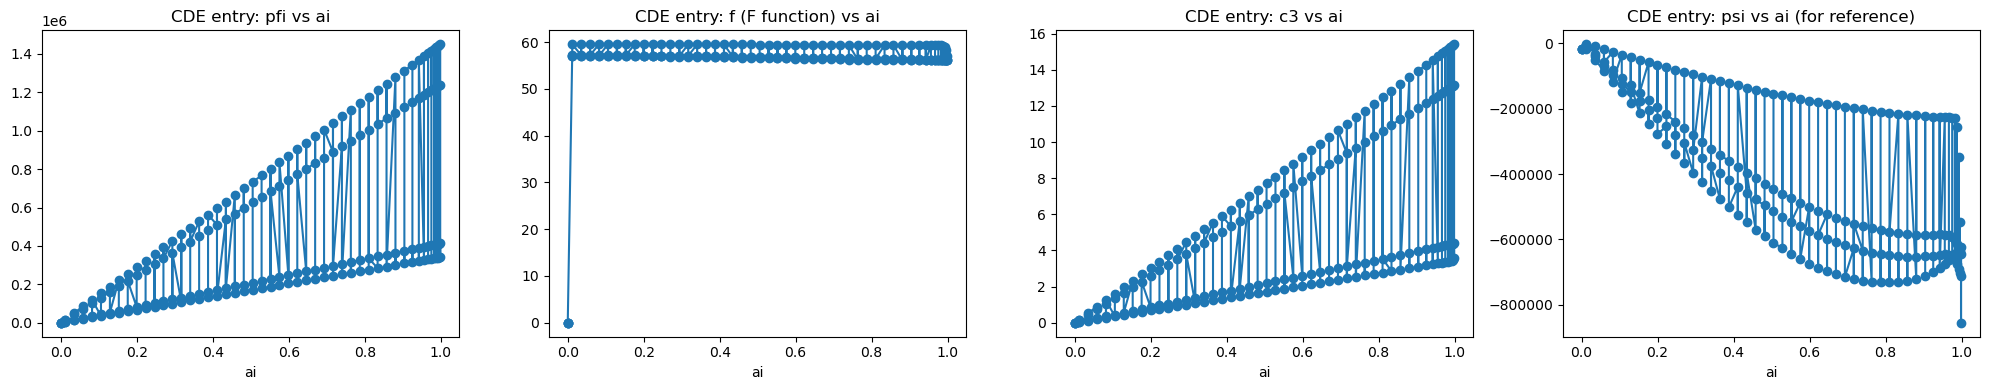

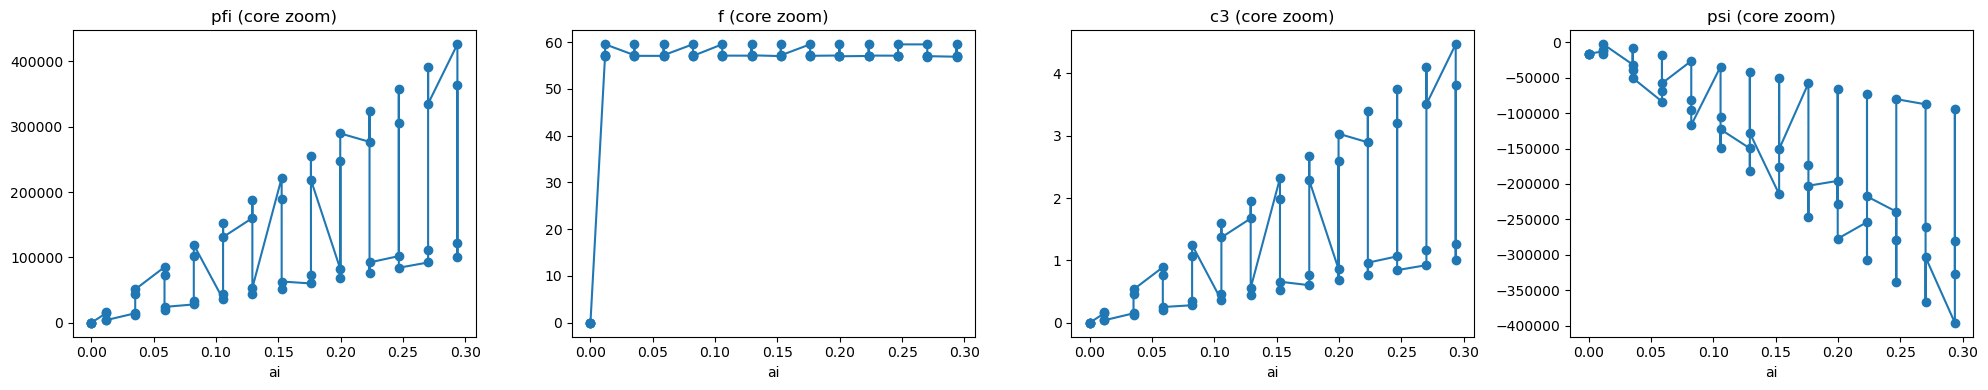

In [45]:
# --- Hypothesis test: is q/psi oscillation caused by irregular grid
# spacing (ha) amplifying noise in the finite-difference psi=(dm0_i -
# dm0_{i-1})/ha_i, even though dm0 itself and the MIDC geometry (c2,c3)
# look smooth? ---
ce_sorted = ce.sort_values('i')

fig5, axs5 = plt.subplots(2, 3, figsize=(16, 8))

# Grid spacing itself
axs5[0,0].plot(ce_sorted.ai, ce_sorted.ha, 'o-')
axs5[0,0].set_title('CDE entry: ha (grid spacing) vs ai')

# Second derivative / local irregularity of ha
d2ha = np.diff(ce_sorted.ha.to_numpy(), n=1)
axs5[0,1].plot(ce_sorted.ai.to_numpy()[1:], d2ha, 'o-')
axs5[0,1].set_title('diff(ha) -- grid-spacing irregularity')

# dm0 itself (should be smooth per the earlier plot)
axs5[0,2].plot(ce_sorted.ai, ce_sorted.dm0, 'o-')
axs5[0,2].set_title('CDE entry: dm0 vs ai')

# Raw finite difference dm0_i - dm0_{i-1} (numerator of psi), BEFORE
# dividing by ha -- if this looks smooth but psi does not, ha is the
# culprit.
d_dm0 = np.diff(ce_sorted.dm0.to_numpy(), n=1)
axs5[1,0].plot(ce_sorted.ai.to_numpy()[1:], d_dm0, 'o-')
axs5[1,0].set_title('diff(dm0)  (numerator of psi)')

# psi and q themselves, for reference
axs5[1,1].plot(ce_sorted.ai, ce_sorted.psi, 'o-')
axs5[1,1].set_title('CDE entry: psi vs ai')

axs5[1,2].plot(ce_sorted.ai, ce_sorted.q, 'o-')
axs5[1,2].set_title('CDE entry: q vs ai')

for ax in axs5.flat:
    ax.set_xlabel('ai')

plt.tight_layout(); plt.show()

# Quantify: is ha itself irregular (jumps in grid spacing)?
print('ha stats: min=%.4g max=%.4g mean=%.4g std=%.4g'
      % (ce_sorted.ha.min(), ce_sorted.ha.max(),
         ce_sorted.ha.mean(), ce_sorted.ha.std()))
print('diff(ha) stats: min=%.4g max=%.4g std=%.4g'
      % (d2ha.min(), d2ha.max(), d2ha.std()))

# --- ha/diff(dm0) are both smooth, yet q still oscillates near the core.
# Since q = -pfi/psi and psi looks smooth here, the culprit must be pfi
# = 2*pi*rs0*c3(i)*f(i). c3 is smooth (MIDC), so check f (poloidal
# current function F) directly -- this is the last untested link in the
# ntay=0 pipeline before TOKK. ---
fig6, axs6 = plt.subplots(1, 4, figsize=(20, 4))

axs6[0].plot(ce_sorted.ai, ce_sorted.pfi, 'o-')
axs6[0].set_title('CDE entry: pfi vs ai')

axs6[1].plot(ce_sorted.ai, ce_sorted.f, 'o-')
axs6[1].set_title('CDE entry: f (F function) vs ai')

axs6[2].plot(ce_sorted.ai, ce_sorted.c3, 'o-')
axs6[2].set_title('CDE entry: c3 vs ai')

axs6[3].plot(ce_sorted.ai, ce_sorted.psi, 'o-')
axs6[3].set_title('CDE entry: psi vs ai (for reference)')

for ax in axs6:
    ax.set_xlabel('ai')

plt.tight_layout(); plt.show()

# Zoom into the core (ai < 0.3) where the q oscillation was visually
# sharpest, for pfi/f/c3/psi side by side.
core = ce_sorted[ce_sorted.ai < 0.3]
fig7, axs7 = plt.subplots(1, 4, figsize=(20, 4))
axs7[0].plot(core.ai, core.pfi, 'o-'); axs7[0].set_title('pfi (core zoom)')
axs7[1].plot(core.ai, core.f, 'o-');   axs7[1].set_title('f (core zoom)')
axs7[2].plot(core.ai, core.c3, 'o-');  axs7[2].set_title('c3 (core zoom)')
axs7[3].plot(core.ai, core.psi, 'o-'); axs7[3].set_title('psi (core zoom)')
for ax in axs7:
    ax.set_xlabel('ai')
plt.tight_layout(); plt.show()


**Consistency check, source: `cde_entry`.** Manually recomputing
`q = -pfi/psi` from the same dumped columns to confirm the dumped `q`
is faithful to the underlying `pfi`/`psi` ratio (i.e. ruling out a
separate bug in how `q` itself is computed/dumped, as opposed to the
oscillation being inherent to dividing by a near-zero `psi`).

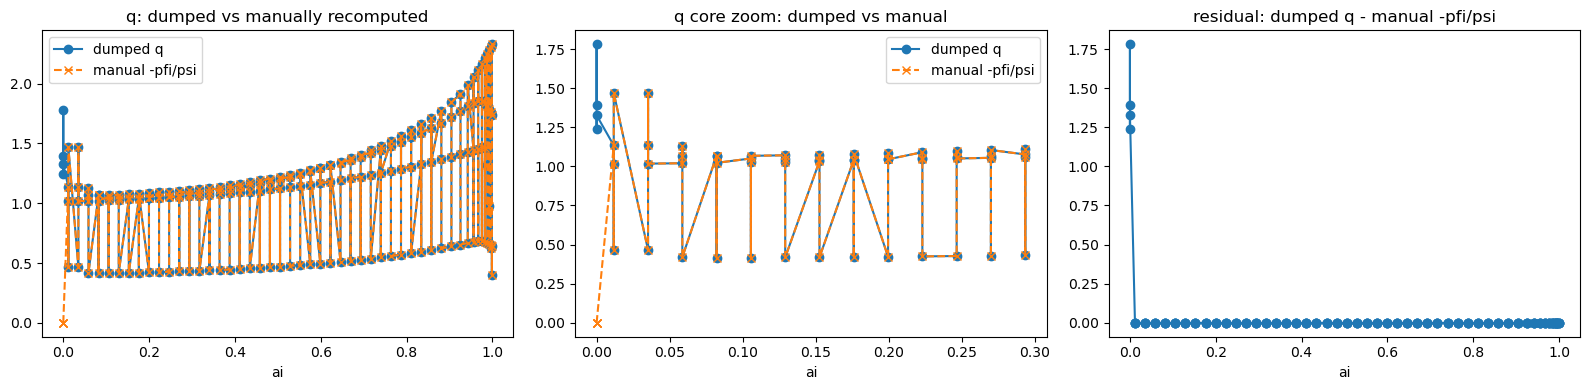

max |residual| = 1.7808391
psi near axis (first 8 points):
      i        ai         pfi         psi         q
1500  1  0.000000      0.0000 -15994.0840  1.394801
1550  1  0.000000      0.0000 -15994.0840  1.780839
1400  1  0.000000      0.0000 -15994.0840  1.240944
1450  1  0.000000      0.0000 -15994.0840  1.326680
1451  2  0.011745  14575.7810 -12853.1830  1.134021
1401  2  0.011745  17052.0560 -16757.7980  1.017559
1501  2  0.011745   4861.2809 -10450.0790  0.465191
1551  2  0.011745   4013.9649  -2729.7698  1.470441


In [46]:
# --- Manually recompute q = -pfi/psi from the dumped pfi and psi
# columns (bypassing the dumped q column entirely) to test whether the
# sharp near-axis oscillation is purely a ratio-amplification artifact
# (both pfi and psi individually look "smooth enough" but -> 0 near the
# axis, so noise/roundoff in either is hugely amplified by the divide),
# as opposed to being introduced by some other bug in q's own dump/path.
q_manual = -ce_sorted.pfi.to_numpy() / ce_sorted.psi.to_numpy()

fig8, axs8 = plt.subplots(1, 3, figsize=(16, 4))

axs8[0].plot(ce_sorted.ai, ce_sorted.q, 'o-', label='dumped q')
axs8[0].plot(ce_sorted.ai, q_manual, 'x--', label='manual -pfi/psi')
axs8[0].set_title('q: dumped vs manually recomputed')
axs8[0].legend()

# Core zoom of the same comparison
core_mask = (ce_sorted.ai < 0.3).to_numpy()
axs8[1].plot(ce_sorted.ai[core_mask], ce_sorted.q.to_numpy()[core_mask],
             'o-', label='dumped q')
axs8[1].plot(ce_sorted.ai[core_mask], q_manual[core_mask],
             'x--', label='manual -pfi/psi')
axs8[1].set_title('q core zoom: dumped vs manual')
axs8[1].legend()

# Residual between dumped and manually-recomputed q -- should be ~0
# everywhere if q's dump is faithful to pfi/psi (i.e. confirms the
# oscillation is inherent to the pfi/psi ratio, not a separate bug).
resid = ce_sorted.q.to_numpy() - q_manual
axs8[2].plot(ce_sorted.ai, resid, 'o-')
axs8[2].set_title('residual: dumped q - manual -pfi/psi')

for ax in axs8:
    ax.set_xlabel('ai')

plt.tight_layout(); plt.show()

print('max |residual| =', np.nanmax(np.abs(resid)))
print('psi near axis (first 8 points):')
print(ce_sorted[['i','ai','pfi','psi','q']].head(8))

**Multi-step overlay, sources: `cde` + `raw`.** Colors by `ntay` (via a
`tt`→`ntay` lookup built from `cde_entry`) to visualize how post-solve
`psi`/`q` (from `cde`) and the resulting `ppx`/`pffx` tables (from `raw`)
evolve step-by-step once `ppx_pffx()` starts firing. Also prints a
per-step `min|psi|` edge-region table to directly test the 1/psi
singularity hypothesis.

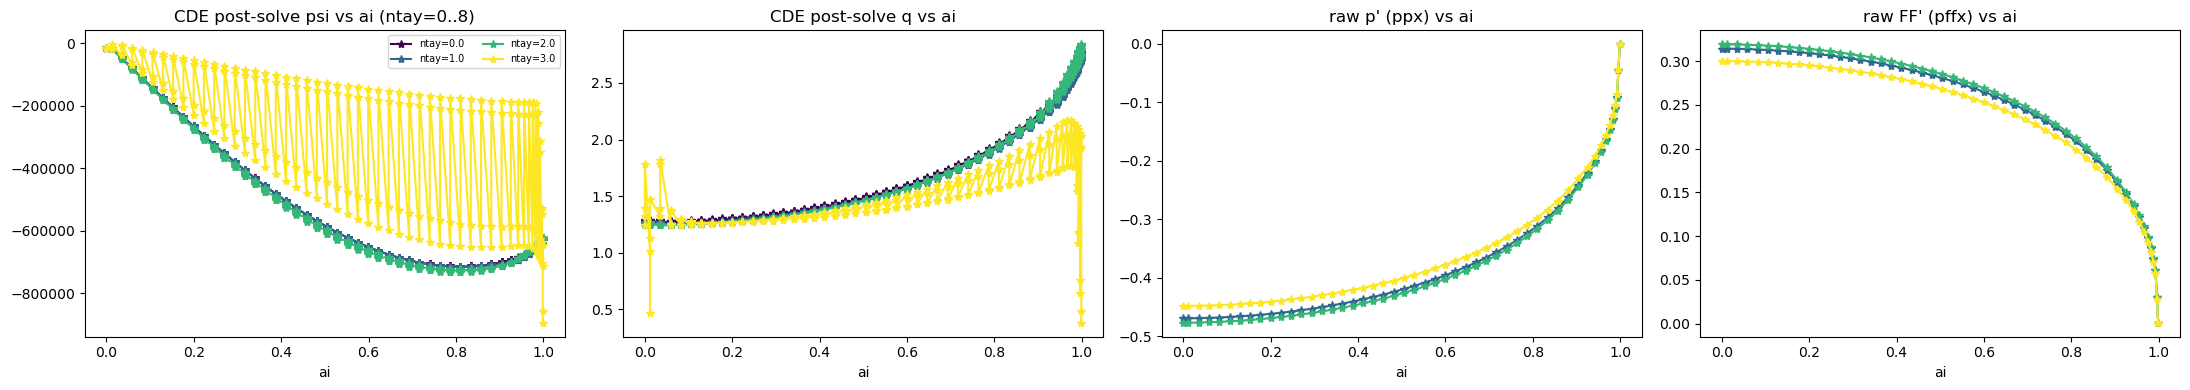

 ntay    min|psi| (ai>0.6)    argmin ai   psi sign change?    max|ppx| edge   max|pffx| edge
  0.0            6.226e+05        0.999              False              nan              nan
  1.0            6.275e+05        0.999              False           0.3894           0.2605
  2.0            6.224e+05        0.999              False           0.3956           0.2646
  3.0             1.49e+05        0.622              False           0.3718           0.2487


In [47]:
# --- Re-check with the NEW ppx_pffx/Robin-BC timing (ppx_pffx first
# fires at ntay=4, Robin-BC warmup override now extends through
# ntay<=3). The Picard solver is now reported to start drifting slowly
# from ntay=4 onward, rather than blowing up outright at ntay=3.
#
# Build a tt -> ntay map from cde_entry (one CDE call per ntay) so we
# can color/overlay raw & tokk (which only carry tt) by ntay too.
tt2ntay = (cde_entry[['tt', 'ntay']]
           .drop_duplicates()
           .set_index('tt')['ntay'])

raw2 = raw.copy()
raw2['ntay'] = raw2['tt'].map(tt2ntay)

ntay_max_check = 8
cde_sub = cde[cde.ntay <= ntay_max_check].sort_values(['ntay', 'i'])
raw_sub = raw2[raw2.ntay <= ntay_max_check].sort_values(['ntay', 'i'])

fig9, axs9 = plt.subplots(1, 4, figsize=(22, 4))
cmap = plt.cm.viridis
ntays = sorted(cde_sub.ntay.unique())
norm = plt.Normalize(min(ntays), max(ntays))

for nt in ntays:
    g = cde_sub[cde_sub.ntay == nt]
    axs9[0].plot(g.ai, g.psi, '*-', color=cmap(norm(nt)), label=f'ntay={nt}')
    axs9[1].plot(g.ai, g.q,   '*-', color=cmap(norm(nt)))

    gr = raw_sub[raw_sub.ntay == nt]
    if len(gr):
        axs9[2].plot(gr.ai, gr.ppx,  '*-', color=cmap(norm(nt)))
        axs9[3].plot(gr.ai, gr.pffx, '*-', color=cmap(norm(nt)))

axs9[0].set_title('CDE post-solve psi vs ai (ntay=0..%d)' % ntay_max_check)
axs9[1].set_title('CDE post-solve q vs ai')
axs9[2].set_title("raw p' (ppx) vs ai")
axs9[3].set_title("raw FF' (pffx) vs ai")
for ax in axs9:
    ax.set_xlabel('ai')
axs9[0].legend(fontsize=7, ncol=2)
plt.tight_layout(); plt.show()

# --- Quantify: does psi ever approach zero / change sign in the edge
# region (ai > 0.6), and how does that evolve step by step? This is
# the direct test of the 1/psi divergence hypothesis in pp_calc, as
# opposed to inferring it from roughness alone.
print(f"{'ntay':>5} {'min|psi| (ai>0.6)':>20} {'argmin ai':>12} "
      f"{'psi sign change?':>18} {'max|ppx| edge':>16} {'max|pffx| edge':>16}")
for nt in ntays:
    g = cde_sub[cde_sub.ntay == nt]
    edge = g[g.ai > 0.6]
    if len(edge) == 0:
        continue
    idx = edge.psi.abs().idxmin()
    min_abs_psi = edge.psi.abs().min()
    ai_at_min = edge.loc[idx, 'ai']
    sign_change = (edge.psi.min() < 0) and (edge.psi.max() > 0)

    gr = raw_sub[raw_sub.ntay == nt]
    edge_r = gr[gr.ai > 0.6]
    max_ppx = edge_r.ppx.abs().max() if len(edge_r) else float('nan')
    max_pffx = edge_r.pffx.abs().max() if len(edge_r) else float('nan')

    print(f"{nt:>5} {min_abs_psi:>20.4g} {ai_at_min:>12.3f} "
          f"{str(sign_change):>18} {max_ppx:>16.4g} {max_pffx:>16.4g}")


**Smoking-gun check, source: `cde` (edge boundary point, `i=n`).** Tracks
`dm0(n)`/`dmn(n)` — the exact quantities entering the Robin BC's `ZDM`
term in `tpl_cal_c` — across `ntay` to find the precise step where they
diverge from the smooth early trend, independent of whether `psi` itself
looks smooth.

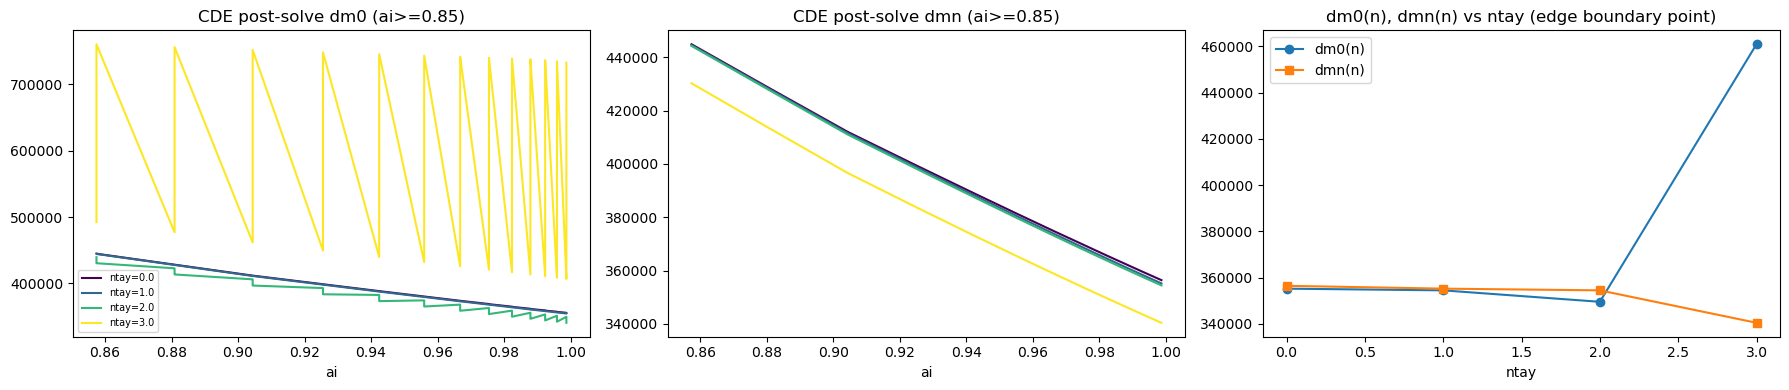

Edge boundary point (i=n) dm0/dmn/psi vs ntay:
 ntay    i       ai       dm0       dmn        psi
  0.0 50.0 0.998739 355178.77 356407.99 -627993.24
  1.0 50.0 0.998739 354438.31 355178.77 -627745.55
  2.0 50.0 0.998739 349488.14 354439.10 -626854.14
  3.0 50.0 0.998739 460936.97 340402.66 -644213.53

Relative step-to-step jump in dmn(n):
ntay
0.0         NaN
1.0   -0.003461
2.0   -0.002087
3.0   -0.041235


In [48]:
# --- Smoking-gun check: does dm0/dmn (the actual CDE flux state used
# in the Robin BC, ZDM=UDM*(-DMN(n)+pll0*tpl0+udd*tay*100.)) jump
# discontinuously right at the ntay=3 -> ntay=4 handoff, i.e. exactly
# when ppx_pffx() first starts consuming CDE output? psi (dPsi/da)
# looked smooth in the previous cell, but dm0/dmn are the integrated
# quantities that actually feed pp_calc/pff_calc via ppx_pffx's own
# re-gridding, so a level offset here (even with a smooth gradient)
# would explain the p'/FF' level shift without any psi singularity.

edge_lo = 0.85  # focus on the near-edge region, a(i) grid

fig10, axs10 = plt.subplots(1, 3, figsize=(18, 4))

for nt in ntays:
    g = cde_sub[cde_sub.ntay == nt]
    ge = g[g.ai >= edge_lo]
    axs10[0].plot(ge.ai, ge.dm0, '-', color=cmap(norm(nt)), label=f'ntay={nt}')
    axs10[1].plot(ge.ai, ge.dmn, '-', color=cmap(norm(nt)))

axs10[0].set_title(f'CDE post-solve dm0 (ai>={edge_lo})')
axs10[1].set_title(f'CDE post-solve dmn (ai>={edge_lo})')
axs10[0].legend(fontsize=7)

# dm0(n) and dmn(n) (very last grid point) vs ntay -- this is exactly
# the DMN(n) term entering ZDM in tpl_cal_c's Robin BC.
last_pt = (cde_sub.sort_values('i')
           .groupby('ntay')
           .tail(1)
           .sort_values('ntay'))
axs10[2].plot(last_pt.ntay, last_pt.dm0, 'o-', label='dm0(n)')
axs10[2].plot(last_pt.ntay, last_pt.dmn, 's-', label='dmn(n)')
axs10[2].set_title('dm0(n), dmn(n) vs ntay (edge boundary point)')
axs10[2].set_xlabel('ntay')
axs10[2].legend()

for ax in axs10[:2]:
    ax.set_xlabel('ai')

plt.tight_layout(); plt.show()

print('Edge boundary point (i=n) dm0/dmn/psi vs ntay:')
print(last_pt[['ntay', 'i', 'ai', 'dm0', 'dmn', 'psi']].to_string(index=False))

# Step-to-step relative jump in dmn(n), to spot a discontinuity right
# at the ntay=3->4 handoff (where ppx_pffx first fires under the new gate).
dmn_n = last_pt.set_index('ntay')['dmn']
rel_jump = dmn_n.diff() / dmn_n.abs()
print('\nRelative step-to-step jump in dmn(n):')
print(rel_jump.to_string())


**Robin BC internals, source: `bc` (`tpl_cal_bc.log`).** Direct read of
`pll`, `pll0`, `tpl`, `tpl0`, `udd`, `UDM`, `ZDM`, and
`mismatch = pll0*tpl0 - DMN(n)` — the actual coefficients DINA computes
for the CDE's boundary condition each `ntay` — to identify which term
first shows a discontinuity.

tpl_cal_bc.log: ntay range 0 -> 3 | n rows: 32

 ntay  regime       pll      pll0       tpl      tpl0  udd      UDM       ZDM     DMN_n     DM0_n   mismatch
    0       0 512.62188 512.62188 2539.7000 2539.7000 -0.0 0.000000 56.933153 356407.99 356407.99  945497.79
    0       0 512.93053 512.93053 2539.7000 2539.7000 -0.0 0.000000 56.933374 356407.99 355504.76  946281.68
    0       0 513.20764 513.20764 2539.7000 2539.7000 -0.0 0.000000 56.933367 356407.99 355183.33  946985.46
    0       0 513.43301 513.43301 2539.7000 2539.7000 -0.0 0.000000 56.933367 356407.99 355184.31  947557.84
    0       0 513.62197 513.62197 2539.7000 2539.7000 -0.0 0.000000 56.933367 356407.99 355185.27  948037.74
    0       0 513.77134 513.77134 2539.7000 2539.7000 -0.0 0.000000 56.933367 356407.99 355184.75  948417.08
    0       0 513.89812 513.89812 2539.7000 2539.7000 -0.0 0.000000 56.933367 356407.99 355183.59  948739.08
    0       0 514.00744 514.00744 2539.7000 2539.7000 -0.0 0.000000 56.933367 35

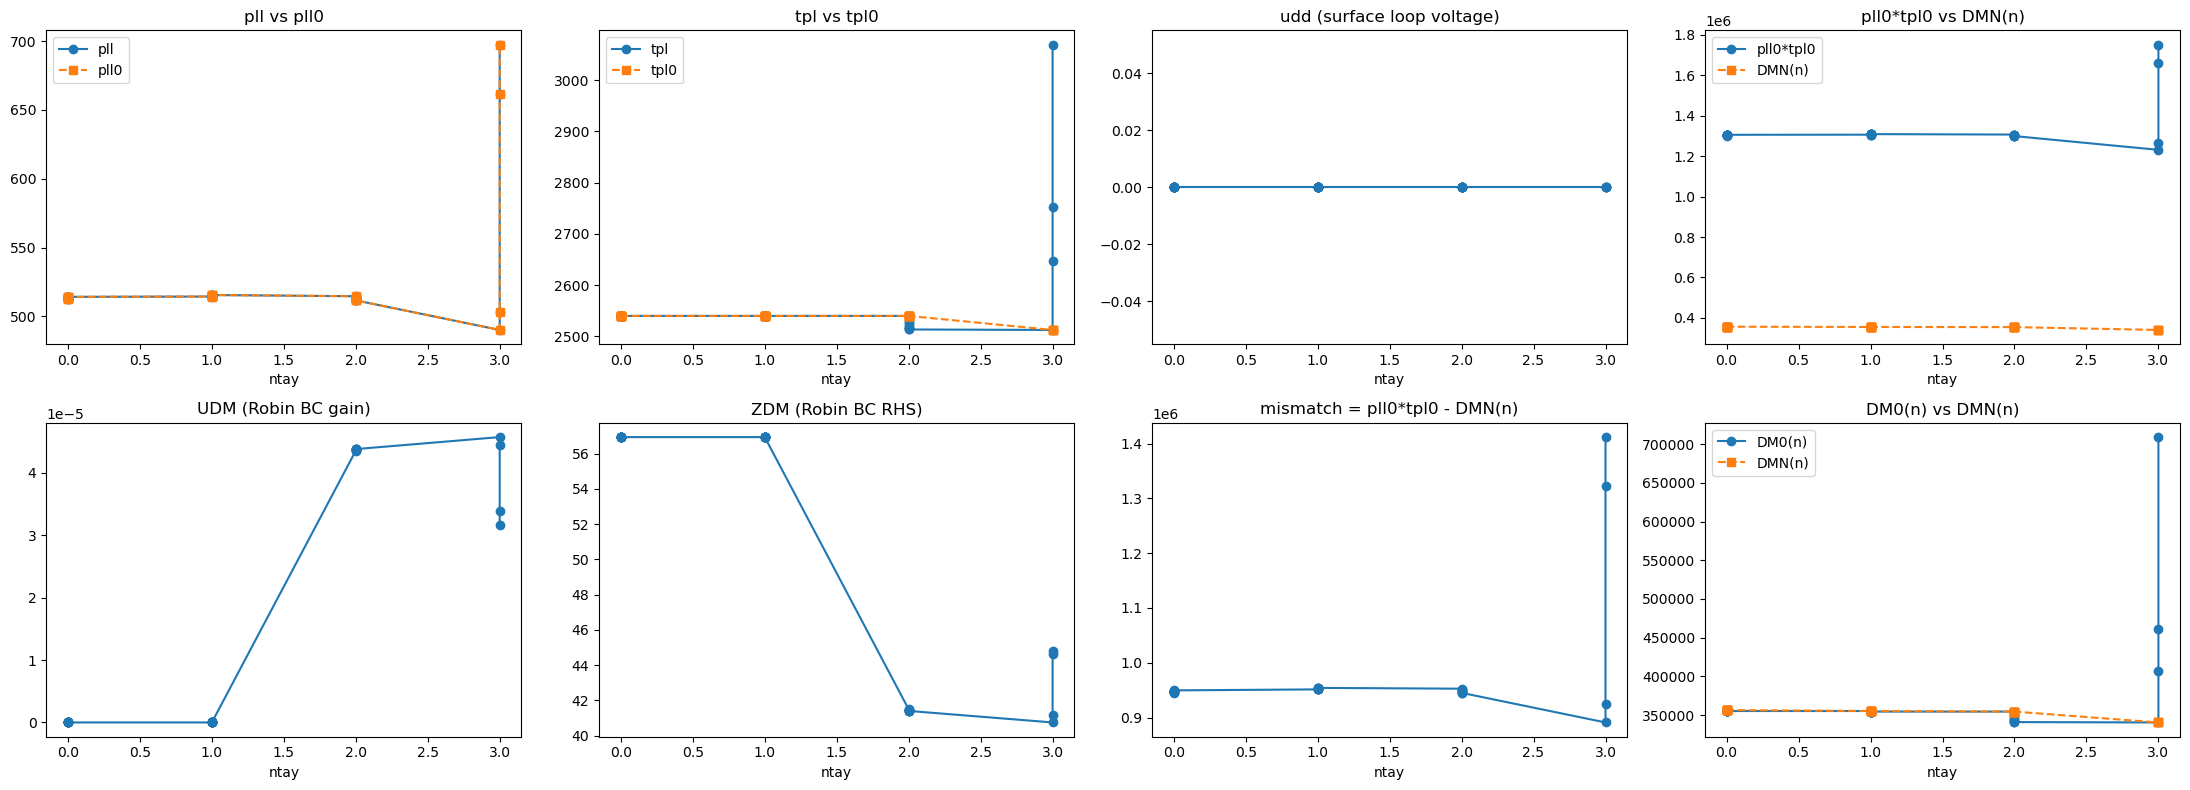


Relative step-to-step jump in pll:
ntay
0         NaN
0    0.000602
0    0.000540
0    0.000439
0    0.000368
0    0.000291
0    0.000247
0    0.000213
0    0.000205
0    0.000268
1    0.000461
1    0.000349
1    0.000242
1    0.000203
1    0.000173
1    0.000165
1    0.000183
1    0.000214
1    0.000274
1    0.000284
2   -0.001692
2   -0.001136
2   -0.001259
2   -0.001061
2   -0.000971
2   -0.000650
2   -0.000412
2   -0.000325
3   -0.043878
3    0.026327
3    0.239353
3    0.051062

Relative step-to-step jump in tpl:
ntay
0         NaN
0    0.000000
0    0.000000
0    0.000000
0    0.000000
0    0.000000
0    0.000000
0    0.000000
0    0.000000
0    0.000000
1    0.000000
1    0.000000
1    0.000000
1    0.000000
1    0.000000
1    0.000000
1    0.000000
1    0.000000
1    0.000000
1    0.000000
2    0.000000
2   -0.003802
2   -0.001503
2   -0.001586
2   -0.001309
2   -0.001115
2   -0.000706
2   -0.000475
3   -0.000375
3    0.050998
3    0.037944
3    0.103556

Relative step-to-step

In [49]:
# --- Robin BC internals: pll, udd, UDM, ZDM, DMN_n, DM0_n, PSI_n, F_n,
# tpl0, pll0, etc. are ALREADY dumped by tpl_cal_c (ndop1_new2_400.f)
# to 'tpl_cal_bc.log', one row per tpl_cal_c call (i.e. per ntay).
# No new Fortran instrumentation needed -- just load & inspect it.
bc_cols = ['ntay', 'tt', 'regime', 'fdd', 'fdd0', 'udd',
           'pll', 'pll0', 'tpl', 'tpl0', 'DMN_n', 'DM0_n', 'PSI_n',
           'F_n', 'UDM', 'ZDM', 'udd_drive', 'pll0_tpl0', 'mismatch',
           'tpl_tor']
bc = pd.read_csv(path_to_file + 'tpl_cal_bc.log', sep=r'\s+',
                  comment='#', names=bc_cols)

bc_check = bc[bc.ntay <= ntay_max_check].sort_values('ntay')

print('tpl_cal_bc.log: ntay range', bc.ntay.min(), '->', bc.ntay.max(),
      '| n rows:', len(bc))
print()
print(bc_check[['ntay', 'regime', 'pll', 'pll0', 'tpl', 'tpl0',
                'udd', 'UDM', 'ZDM', 'DMN_n', 'DM0_n',
                'mismatch']].to_string(index=False))

fig11, axs11 = plt.subplots(2, 4, figsize=(22, 8))

axs11[0,0].plot(bc_check.ntay, bc_check.pll, 'o-', label='pll')
axs11[0,0].plot(bc_check.ntay, bc_check.pll0, 's--', label='pll0')
axs11[0,0].set_title('pll vs pll0'); axs11[0,0].legend()

axs11[0,1].plot(bc_check.ntay, bc_check.tpl, 'o-', label='tpl')
axs11[0,1].plot(bc_check.ntay, bc_check.tpl0, 's--', label='tpl0')
axs11[0,1].set_title('tpl vs tpl0'); axs11[0,1].legend()

axs11[0,2].plot(bc_check.ntay, bc_check.udd, 'o-')
axs11[0,2].set_title('udd (surface loop voltage)')

axs11[0,3].plot(bc_check.ntay, bc_check.pll0_tpl0, 'o-', label='pll0*tpl0')
axs11[0,3].plot(bc_check.ntay, bc_check.DMN_n, 's--', label='DMN(n)')
axs11[0,3].set_title('pll0*tpl0 vs DMN(n)'); axs11[0,3].legend()

axs11[1,0].plot(bc_check.ntay, bc_check.UDM, 'o-')
axs11[1,0].set_title('UDM (Robin BC gain)')

axs11[1,1].plot(bc_check.ntay, bc_check.ZDM, 'o-')
axs11[1,1].set_title('ZDM (Robin BC RHS)')

axs11[1,2].plot(bc_check.ntay, bc_check.mismatch, 'o-')
axs11[1,2].set_title('mismatch = pll0*tpl0 - DMN(n)')

axs11[1,3].plot(bc_check.ntay, bc_check.DM0_n, 'o-', label='DM0(n)')
axs11[1,3].plot(bc_check.ntay, bc_check.DMN_n, 's--', label='DMN(n)')
axs11[1,3].set_title('DM0(n) vs DMN(n)'); axs11[1,3].legend()

for ax in axs11.flat:
    ax.set_xlabel('ntay')

plt.tight_layout(); plt.show()

# Step-to-step relative jumps for the key candidate drivers, to see
# which one first shows a discontinuity at the ntay=3->4 handoff.
bc_idx = bc_check.set_index('ntay')
for col in ['pll', 'tpl', 'udd', 'UDM', 'ZDM', 'mismatch']:
    s = bc_idx[col]
    rel = s.diff() / s.abs().replace(0, np.nan)
    print(f'\nRelative step-to-step jump in {col}:')
    print(rel.to_string())


**Back to the ORIGINAL question, source: `cde` (full profile, all `i`).**
The edge-point (`i=n`) analysis above tested the Robin-BC hypothesis and
ruled it out as the explanation for a *whole-profile* staircase (the BC
formula only ever touches `dm0(n)` directly, so it cannot by itself
explain teeth at interior grid points). This cell goes back to the
original observation: a jagged/staircase pattern across the **entire**
`dm0(a)` profile that is smoothed away in `dmn(a)` (since `dmn` comes
from re-interpolating the *previous* step's `dm0`). We overlay full
`dm0`/`dmn` profiles per `ntay`, and compute a per-point
`dm0(i) - dmn(i)` "discrepancy" profile and a roughness-vs-`ai` map to
locate *where* along the profile (not just at the edge) the staircase
is largest and how it evolves with `ntay`.

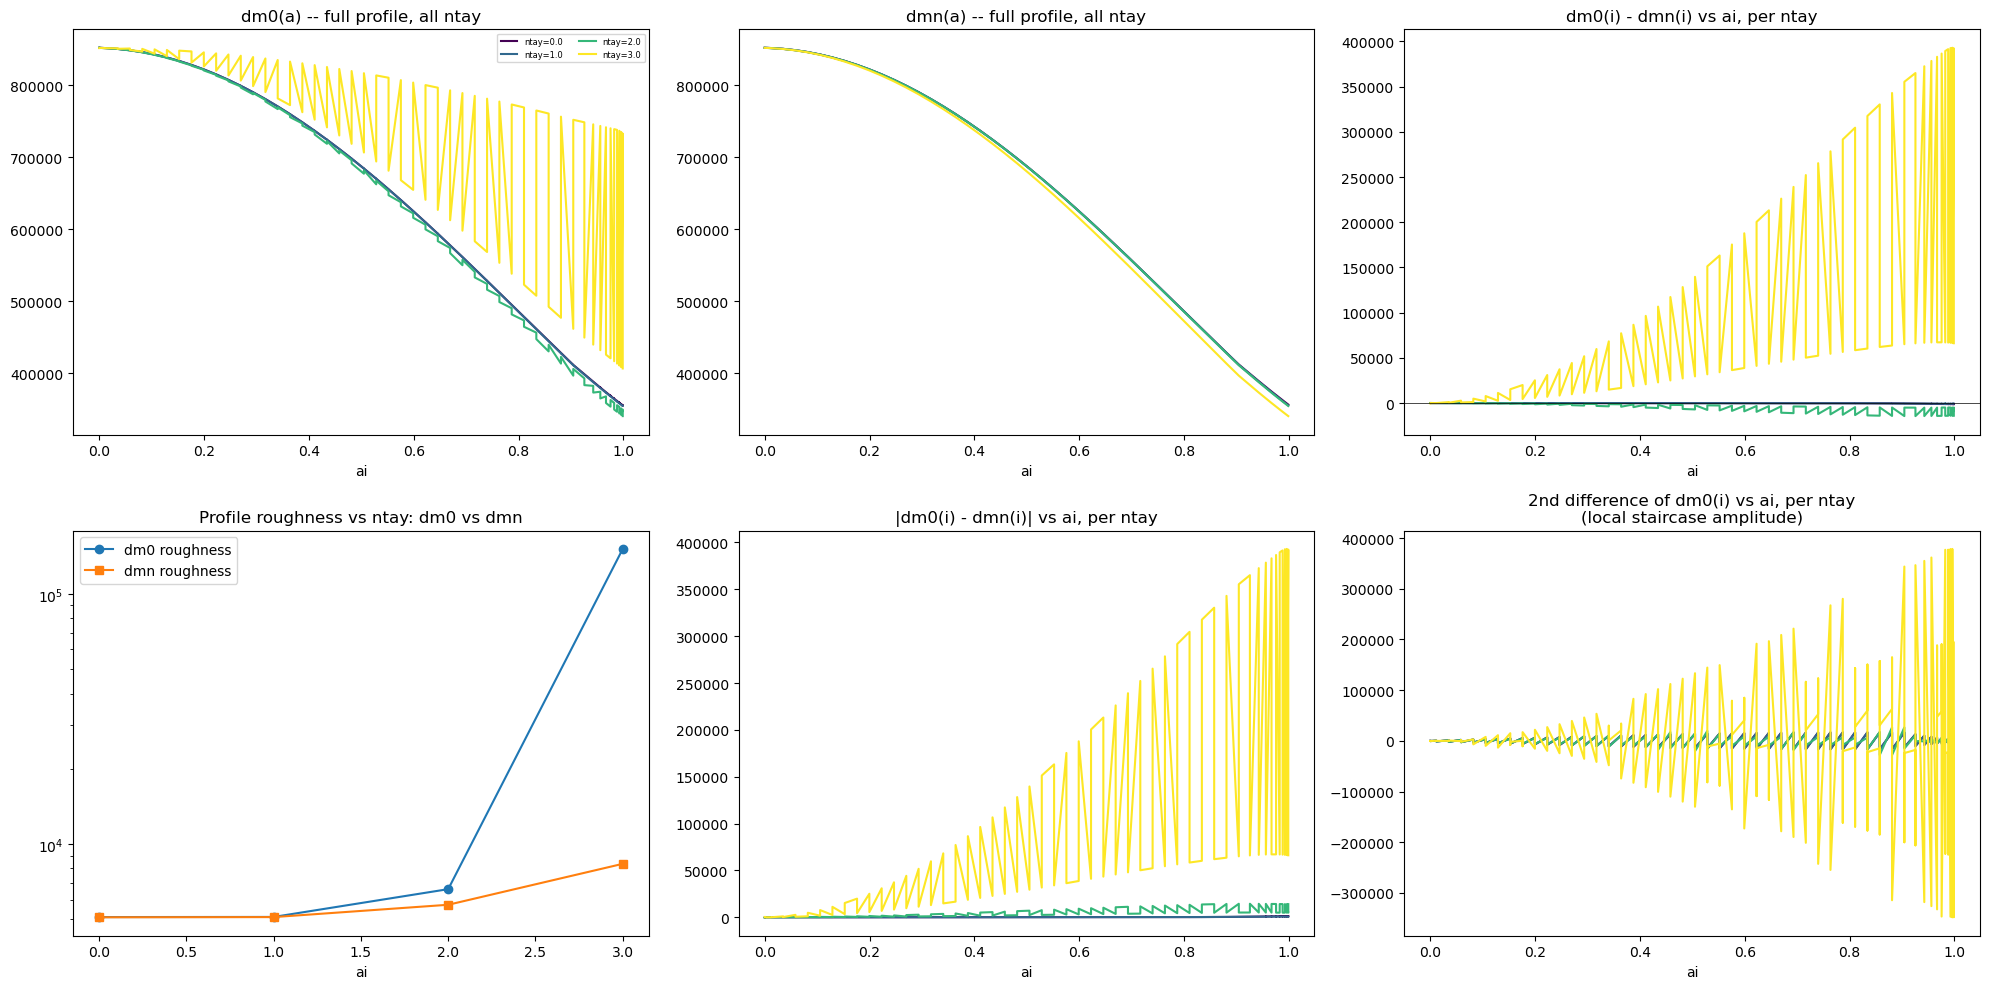

Roughness comparison (dm0 vs dmn), all ntay:
 ntay  dm0_roughness  dmn_roughness  ratio_dm0_over_dmn
  0.0    5105.790367    5094.772638            1.002163
  1.0    5111.975743    5104.558229            1.001453
  2.0    6602.192935    5718.278997            1.154577
  3.0  151421.258474    8336.236277           18.164223


In [50]:
# --- Whole-profile staircase check: dm0(i) vs dmn(i) for ALL i, not
# just the edge point i=n. If dm0 has a staircase/jagged shape that
# dmn does not, it should show up as (a) visible "teeth" in the dm0(i)
# curve overlaid across ntay, and (b) a systematically larger
# point-to-point second-difference (roughness) in dm0 than in dmn at
# the SAME ntay.

fig13, axs13 = plt.subplots(2, 3, figsize=(20, 10))

for nt in ntays:
    g = cde_sub[cde_sub.ntay == nt].sort_values('i')
    axs13[0, 0].plot(g.ai, g.dm0, '-', color=cmap(norm(nt)), label=f'ntay={nt}')
    axs13[0, 1].plot(g.ai, g.dmn, '-', color=cmap(norm(nt)))

axs13[0, 0].set_title('dm0(a) -- full profile, all ntay')
axs13[0, 1].set_title('dmn(a) -- full profile, all ntay')
axs13[0, 0].legend(fontsize=6, ncol=2)

# Per-point discrepancy dm0(i) - dmn(i), same ntay, vs ai -- this
# isolates exactly where along the profile dm0 diverges from the
# smooth dmn re-gridding.
for nt in ntays:
    g = cde_sub[cde_sub.ntay == nt].sort_values('i')
    axs13[0, 2].plot(g.ai, g.dm0 - g.dmn, '-', color=cmap(norm(nt)))
axs13[0, 2].set_title('dm0(i) - dmn(i) vs ai, per ntay')
axs13[0, 2].axhline(0, color='k', lw=0.5)

# Roughness (std of 2nd difference along the grid) computed PER ntay,
# for dm0 and dmn separately -- direct, quantitative test of "dm0 is
# jagged, dmn is not", replacing the single-point-only view.
rough_dm0_ntay = roughness(cde_sub, 'dm0', group_col='ntay')
rough_dmn_ntay = roughness(cde_sub, 'dmn', group_col='ntay')

axs13[1, 0].plot(rough_dm0_ntay.ntay, rough_dm0_ntay.dm0_roughness, 'o-',
                 label='dm0 roughness')
axs13[1, 0].plot(rough_dmn_ntay.ntay, rough_dmn_ntay.dmn_roughness, 's-',
                 label='dmn roughness')
axs13[1, 0].set_title('Profile roughness vs ntay: dm0 vs dmn')
axs13[1, 0].set_xlabel('ntay')
axs13[1, 0].legend()
axs13[1, 0].set_yscale('log')

# Where along ai is the |dm0-dmn| discrepancy largest, per ntay? (i.e.
# is the staircase concentrated at the edge, the core, or spread out?)
for nt in ntays:
    g = cde_sub[cde_sub.ntay == nt].sort_values('i')
    axs13[1, 1].plot(g.ai, (g.dm0 - g.dmn).abs(), '-', color=cmap(norm(nt)))
axs13[1, 1].set_title('|dm0(i) - dmn(i)| vs ai, per ntay')

# Second-difference (local jaggedness) of dm0 vs ai, per ntay, to
# directly visualize WHERE the "teeth" sit along the profile (as
# opposed to just a single roughness scalar per step).
for nt in ntays:
    g = cde_sub[cde_sub.ntay == nt].sort_values('i')
    v = g.dm0.to_numpy()
    ai_v = g.ai.to_numpy()
    if len(v) < 3:
        continue
    d2 = np.diff(v, n=2)
    axs13[1, 2].plot(ai_v[1:-1], d2, '-', color=cmap(norm(nt)))
axs13[1, 2].set_title('2nd difference of dm0(i) vs ai, per ntay\n(local staircase amplitude)')

for ax in axs13.flat:
    ax.set_xlabel('ai')

plt.tight_layout(); plt.show()

print('Roughness comparison (dm0 vs dmn), all ntay:')
rough_cmp = rough_dm0_ntay.merge(rough_dmn_ntay, on='ntay')
rough_cmp['ratio_dm0_over_dmn'] = (rough_cmp.dm0_roughness
                                   / rough_cmp.dmn_roughness)
print(rough_cmp.to_string(index=False))

**Where does the noise first appear: solve inputs vs solve outputs vs
advective coefficients?** `PROGP`'s tridiagonal backward-Euler diffusion
solve is unconditionally stable and itself smoothing, so it should not
*manufacture* grid-scale noise from a smooth input. If `dm0` roughens
starting `ntay~6`, the noise should already be visible **going in** to
`DIFMF` (in `cde_entry`'s `q`/`pfi`, pre-solve) if the source is
upstream (`ppx_pffx`/`TOKK`/`MIDC` feeding back via the *next* step's
coefficients), OR it should appear in the **advective** terms `dfma`/
`dfmax`/`gk` (which are not guaranteed to be damping, unlike the
diffusive part) even when the plain diffusive output stays smooth.
This cell computes roughness vs `ntay` for `cde_entry.q`/`cde_entry.pfi`
(pre-solve inputs) and `cde.dfma`/`cde.dfmax`/`cde.gk` (advective
coefficients), on the SAME ntay axis as the `dm0`/`dmn` roughness above,
to see which one starts climbing first.

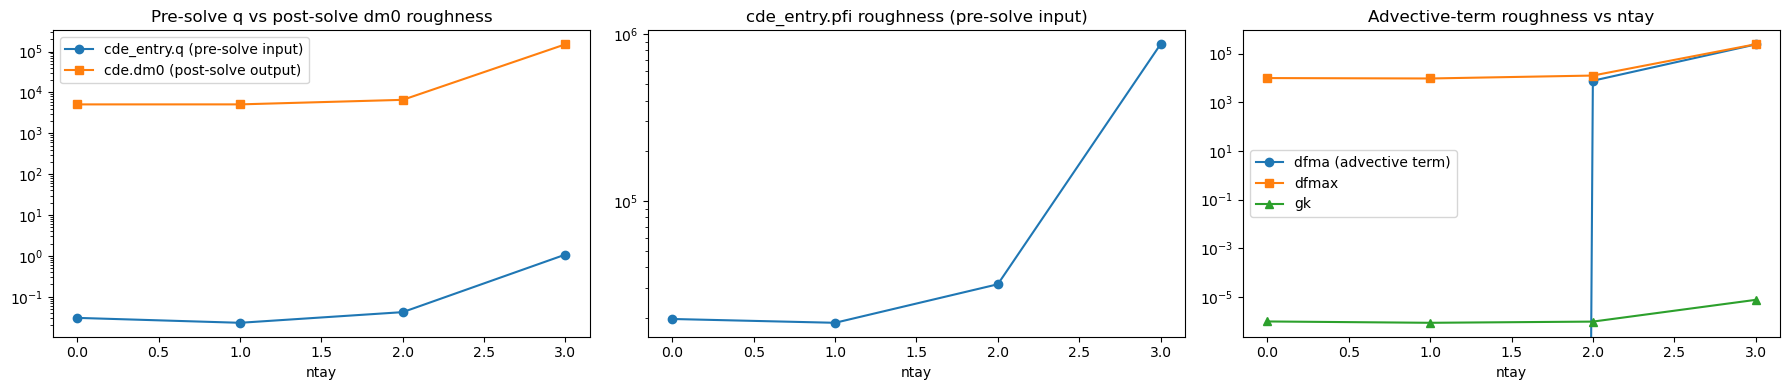

Pre-solve (cde_entry) q/pfi roughness vs ntay:
 ntay  q_roughness  pfi_roughness
    0     0.030374   19656.656603
    1     0.023028   18651.334608
    2     0.042004   31736.786398
    3     1.078865  869680.688463

Advective-term roughness vs ntay (dfma/dfmax/gk):
 ntay  dfma_roughness  dfmax_roughness  gk_roughness
  0.0        0.000000      9825.280929  9.697571e-07
  1.0        0.000000      9446.251211  8.541786e-07
  2.0     7633.054468     12459.813594  9.563699e-07
  3.0   236813.571882    241092.421055  7.486414e-06


In [51]:
# --- Roughness of the CDE's INPUTS (cde_entry, pre-solve) and of the
# ADVECTIVE coefficients (cde.dfma/dfmax/gk) vs ntay, compared on the
# same axis as dm0/dmn roughness, to localize where jaggedness first
# appears in the pipeline relative to the ntay=3/4 ppx_pffx activation.
cde_entry_sub = cde_entry[cde_entry.ntay <= ntay_max_check]

rough_ce_q   = roughness(cde_entry_sub, 'q', group_col='ntay')
rough_ce_pfi = roughness(cde_entry_sub, 'pfi', group_col='ntay')
rough_dfma   = roughness(cde_sub, 'dfma', group_col='ntay')
rough_dfmax  = roughness(cde_sub, 'dfmax', group_col='ntay')
rough_gk     = roughness(cde_sub, 'gk', group_col='ntay')

fig14, axs14 = plt.subplots(1, 3, figsize=(18, 4))

axs14[0].plot(rough_ce_q.ntay, rough_ce_q.q_roughness, 'o-',
              label='cde_entry.q (pre-solve input)')
axs14[0].plot(rough_dm0_ntay.ntay, rough_dm0_ntay.dm0_roughness, 's-',
              label='cde.dm0 (post-solve output)')
axs14[0].set_title('Pre-solve q vs post-solve dm0 roughness')
axs14[0].set_yscale('log'); axs14[0].legend()

axs14[1].plot(rough_ce_pfi.ntay, rough_ce_pfi.pfi_roughness, 'o-')
axs14[1].set_title('cde_entry.pfi roughness (pre-solve input)')
axs14[1].set_yscale('log')

axs14[2].plot(rough_dfma.ntay, rough_dfma.dfma_roughness, 'o-',
              label='dfma (advective term)')
axs14[2].plot(rough_dfmax.ntay, rough_dfmax.dfmax_roughness, 's-',
              label='dfmax')
axs14[2].plot(rough_gk.ntay, rough_gk.gk_roughness, '^-', label='gk')
axs14[2].set_title('Advective-term roughness vs ntay')
axs14[2].set_yscale('log'); axs14[2].legend()

for ax in axs14:
    ax.set_xlabel('ntay')

plt.tight_layout(); plt.show()

print('Pre-solve (cde_entry) q/pfi roughness vs ntay:')
print(rough_ce_q.merge(rough_ce_pfi, on='ntay').to_string(index=False))
print('\nAdvective-term roughness vs ntay (dfma/dfmax/gk):')
print(rough_dfma.merge(rough_dfmax, on='ntay').merge(rough_gk, on='ntay')
      .to_string(index=False))

**Is `dfmax` really just `a(i)^2 * fmax` (a scalar times a smooth
shape)? No.** That formula (`ndop1_new2_400.f` line ~1497) is only the
*first guess* inside an iterative loop (`transf_b_tor`, `it_int`
Picard-like iteration on the toroidal-flux/poloidal-current mapping).
Once the iteration converges (`err`,`errp` < 1e-5), `dfmax(i)` is
**overwritten** with `dfmaxc(i)` — a cumulative sum
`dfmaxc(i)=dfmaxc(i-1)+pfi(i)*ha(i)`. Since `pfi(i)` is exactly the
quantity we already found to be rough (roughness ~900-1200 vs `q`'s
~0.05), any jaggedness in `pfi` gets carried straight into `dfmaxc`
→ `dfmax` → `dfmax0` → `dfma`, profile-wide — no scalar and no
re-gridding needed to explain it.

New dump `dfmax_profiles.dat` (via `dina_dump_dfmax`, called right
after the final `dfmax(i)=dfmaxc(i)` assignment in `transf_b_tor`)
captures the actual per-`i` ingredients: `pfi`, `ha`, `dfmaxc`,
`dfmax_help` (previous `it_int` iterate, for convergence — NOT the
time-previous `dfmax0`), plus `psi`/`q` for cross-reference and
`it_int`/`err`/`errp` convergence diagnostics. This cell loads it and
checks roughness of `pfi` and `dfmaxc` vs `ntay`, side by side with the
`dfma`/`dfmax` roughness already computed, to confirm the propagation.


dfmax_profiles.dat: ntay range 0 -> 3 | n rows: 1650


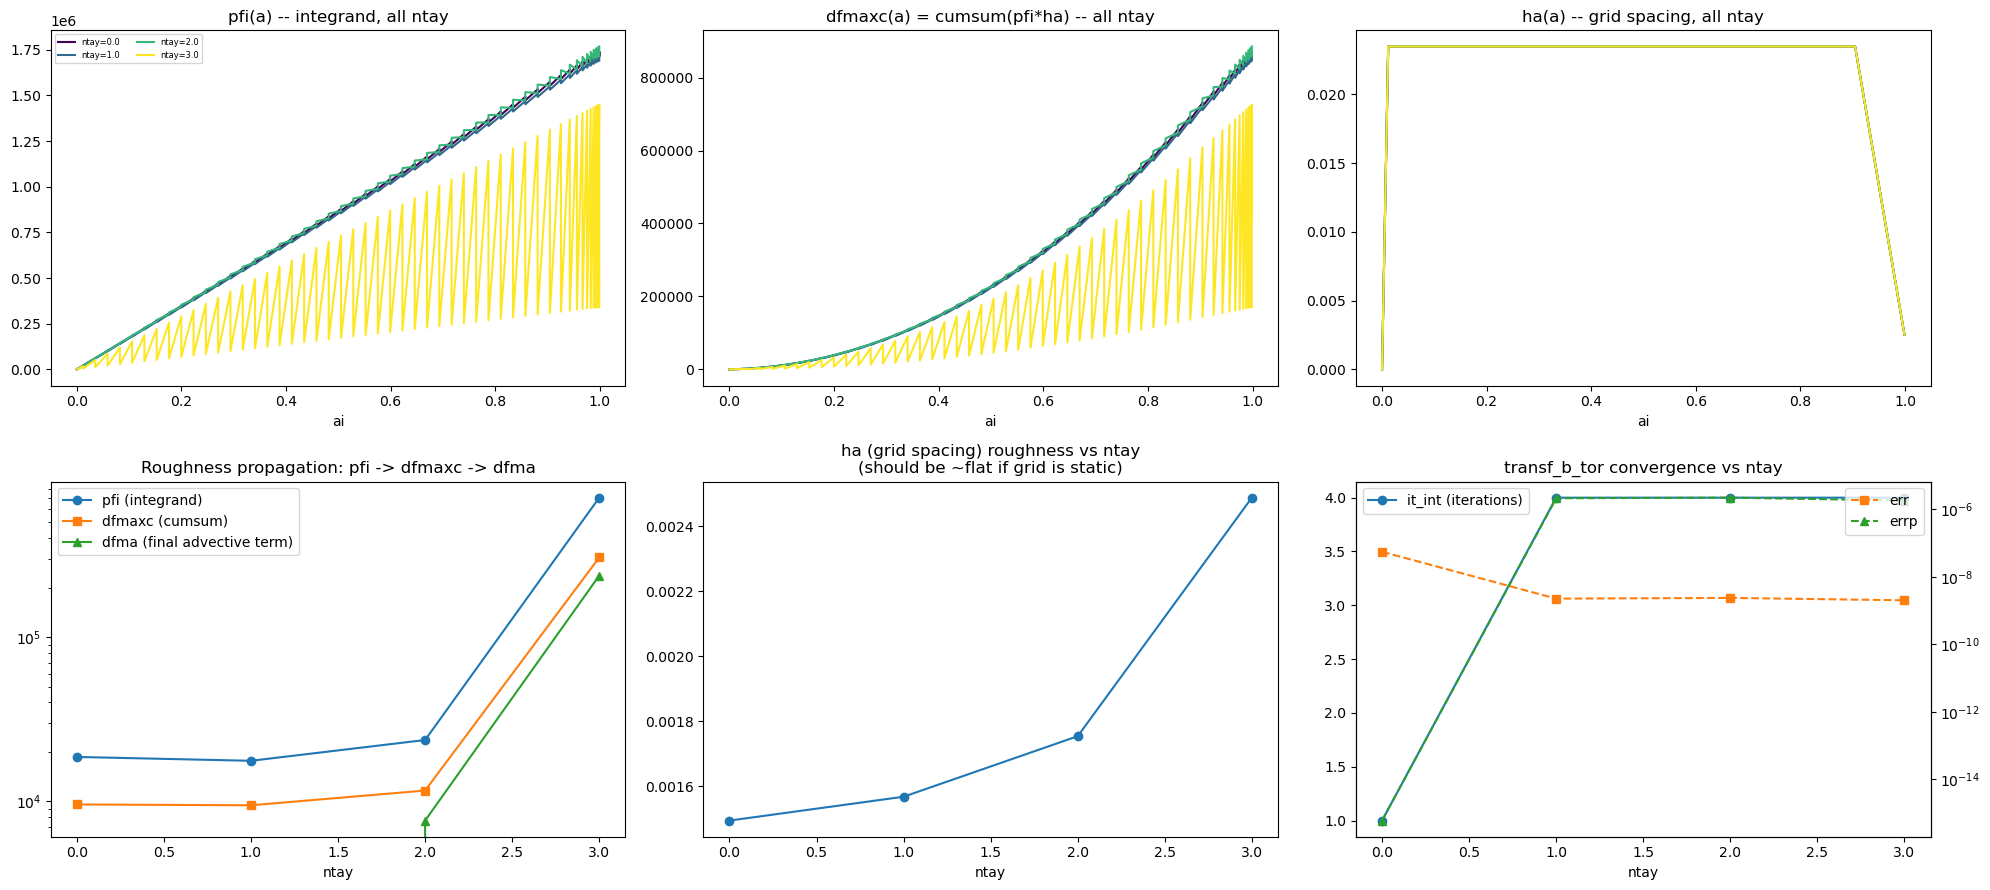

Roughness propagation pfi -> dfmaxc -> dfma, vs ntay:
 ntay  pfi_roughness  dfmaxc_roughness  dfma_roughness
    0   18627.253719       9567.267922        0.000000
    1   17649.711460       9459.011552        0.000000
    2   23616.142781      11628.080572     7633.054468
    3  706018.623205     305350.828462   236813.571882

Convergence diagnostics (it_int/err/errp) vs ntay:
 ntay  it_int          err         errp
    0       1 5.580123e-08 6.059587e-16
    1       4 2.284070e-09 2.151679e-06
    2       4 2.401867e-09 2.238771e-06
    3       4 2.037327e-09 1.845510e-06


In [52]:
dfmax_cols = ['tt', 'ntay', 'i', 'a', 'ai', 'pfi', 'ha', 'dfmaxc',
              'dfmax_help', 'psi', 'q', 'it_int', 'err', 'errp']
dfm = pd.read_csv(path_to_file + 'dfmax_profiles.dat', sep=r'\s+',
                   comment='#', names=dfmax_cols)

print('dfmax_profiles.dat: ntay range', dfm.ntay.min(), '->', dfm.ntay.max(),
      '| n rows:', len(dfm))

dfm_sub = dfm[dfm.ntay <= ntay_max_check].sort_values(['ntay', 'i'])

rough_pfi2    = roughness(dfm_sub, 'pfi', group_col='ntay')
rough_dfmaxc  = roughness(dfm_sub, 'dfmaxc', group_col='ntay')
rough_ha2     = roughness(dfm_sub, 'ha', group_col='ntay')

fig15, axs15 = plt.subplots(2, 3, figsize=(20, 9))

for nt in ntays:
    g = dfm_sub[dfm_sub.ntay == nt]
    axs15[0, 0].plot(g.ai, g.pfi, '-', color=cmap(norm(nt)), label=f'ntay={nt}')
    axs15[0, 1].plot(g.ai, g.dfmaxc, '-', color=cmap(norm(nt)))
    axs15[0, 2].plot(g.ai, g.ha, '-', color=cmap(norm(nt)))

axs15[0, 0].set_title('pfi(a) -- integrand, all ntay')
axs15[0, 0].legend(fontsize=6, ncol=2)
axs15[0, 1].set_title('dfmaxc(a) = cumsum(pfi*ha) -- all ntay')
axs15[0, 2].set_title('ha(a) -- grid spacing, all ntay')

axs15[1, 0].plot(rough_pfi2.ntay, rough_pfi2.pfi_roughness, 'o-',
                  label='pfi (integrand)')
axs15[1, 0].plot(rough_dfmaxc.ntay, rough_dfmaxc.dfmaxc_roughness, 's-',
                  label='dfmaxc (cumsum)')
axs15[1, 0].plot(rough_dfma.ntay, rough_dfma.dfma_roughness, '^-',
                  label='dfma (final advective term)')
axs15[1, 0].set_title('Roughness propagation: pfi -> dfmaxc -> dfma')
axs15[1, 0].set_xlabel('ntay'); axs15[1, 0].set_yscale('log'); axs15[1, 0].legend()

axs15[1, 1].plot(rough_ha2.ntay, rough_ha2.ha_roughness, 'o-')
axs15[1, 1].set_title('ha (grid spacing) roughness vs ntay\n'
                       '(should be ~flat if grid is static)')
axs15[1, 1].set_xlabel('ntay')

# it_int/err/errp convergence diagnostics vs ntay (one value per ntay,
# take first row since it's constant across i within a call)
conv = (dfm_sub.groupby('ntay')[['it_int', 'err', 'errp']]
        .first().reset_index())
axs15[1, 2].plot(conv.ntay, conv.it_int, 'o-', label='it_int (iterations)')
ax_twin = axs15[1, 2].twinx()
ax_twin.plot(conv.ntay, conv.err, 's--', color='tab:orange', label='err')
ax_twin.plot(conv.ntay, conv.errp, '^--', color='tab:green', label='errp')
ax_twin.set_yscale('log')
axs15[1, 2].set_title('transf_b_tor convergence vs ntay')
axs15[1, 2].set_xlabel('ntay')
axs15[1, 2].legend(loc='upper left')
ax_twin.legend(loc='upper right')

for ax in axs15[0]:
    ax.set_xlabel('ai')

plt.tight_layout(); plt.show()

print('Roughness propagation pfi -> dfmaxc -> dfma, vs ntay:')
print(rough_pfi2.merge(rough_dfmaxc, on='ntay')
      .merge(rough_dfma, on='ntay').to_string(index=False))
print('\nConvergence diagnostics (it_int/err/errp) vs ntay:')
print(conv.to_string(index=False))


copy this notebook to the correct uri 

In [53]:
import shutil
import ipynbname


current_nb_path = ipynbname.path()
destination_path = '/scratch/users/svantnj/output/tcv/test_vns_setup/3_with_dmn_fix_with_one2d_fix_ppxGate_ntay5/'
# destination_path = '/scratch/users/svantnj/output/tcv/test_vns_setup/3_with_dmn_fix_with_one2d_fix/'
if True:
    shutil.copy(current_nb_path, destination_path)
    print(f"Copied {current_nb_path.name} to {destination_path}")

Copied debug_plots.ipynb to /scratch/users/svantnj/output/tcv/test_vns_setup/3_with_dmn_fix_with_one2d_fix_ppxGate_ntay5/


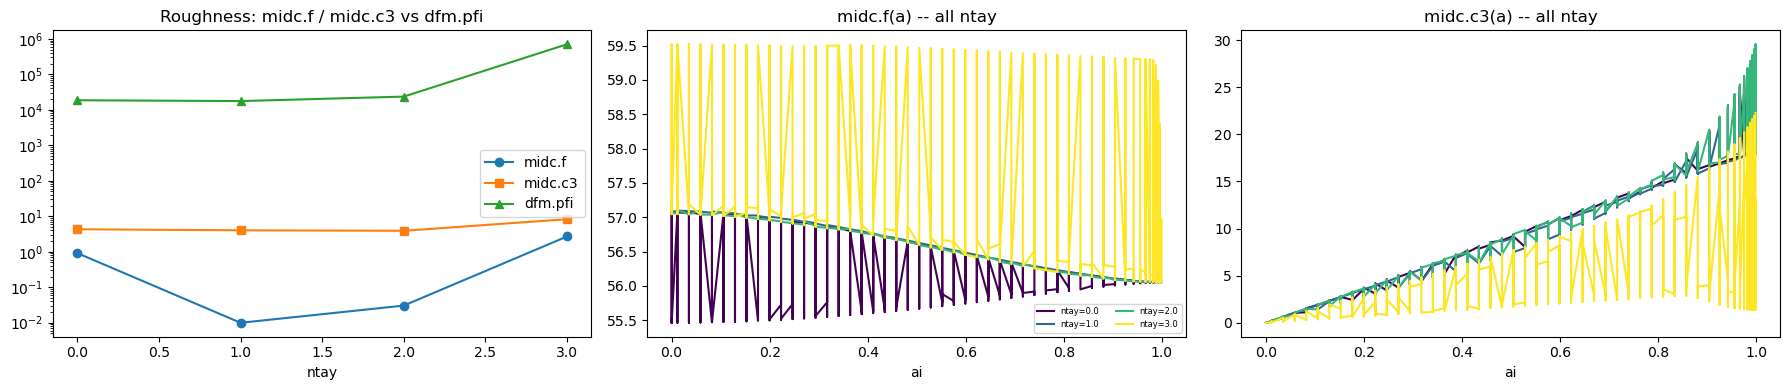

Roughness comparison: midc.f / midc.c3 / dfm.pfi vs ntay:
 ntay  f_roughness  c3_roughness  pfi_roughness
    0     0.911456      4.291873   18627.253719
    1     0.009905      4.015242   17649.711460
    2     0.030292      3.889373   23616.142781
    3     2.684668      8.249112  706018.623205


In [54]:
midc_sub = midc.copy()
midc_sub['ntay'] = midc_sub['tt'].map(tt2ntay)
midc_sub = midc_sub[midc_sub.ntay <= ntay_max_check].dropna(subset=['ntay'])
midc_sub['ntay'] = midc_sub['ntay'].astype(int)

rough_midc_f  = roughness(midc_sub, 'f', group_col='ntay')
rough_midc_c3 = roughness(midc_sub, 'c3', group_col='ntay')

fig16, axs16 = plt.subplots(1, 3, figsize=(18, 4))

axs16[0].plot(rough_midc_f.ntay, rough_midc_f.f_roughness, 'o-',
              label='midc.f')
axs16[0].plot(rough_midc_c3.ntay, rough_midc_c3.c3_roughness, 's-',
              label='midc.c3')
axs16[0].plot(rough_pfi2.ntay, rough_pfi2.pfi_roughness, '^-',
              label='dfm.pfi')
axs16[0].set_title('Roughness: midc.f / midc.c3 vs dfm.pfi')
axs16[0].set_xlabel('ntay'); axs16[0].set_yscale('log'); axs16[0].legend()

for nt in ntays:
    g = midc_sub[midc_sub.ntay == nt].sort_values('i')
    axs16[1].plot(g.ai, g.f, '-', color=cmap(norm(nt)), label=f'ntay={nt}')
    axs16[2].plot(g.ai, g.c3, '-', color=cmap(norm(nt)))

axs16[1].set_title('midc.f(a) -- all ntay')
axs16[1].legend(fontsize=6, ncol=2)
axs16[2].set_title('midc.c3(a) -- all ntay')

for ax in axs16[1:]:
    ax.set_xlabel('ai')

plt.tight_layout(); plt.show()

print('Roughness comparison: midc.f / midc.c3 / dfm.pfi vs ntay:')
print(rough_midc_f.merge(rough_midc_c3, on='ntay')
      .merge(rough_pfi2, on='ntay').to_string(index=False))


**Converging further: is `pfi`'s jaggedness coming from `f(i)` or from
`c3(i)`?** Inside `transf_b_tor`, `pfi(i)=2*pi*rs0*c3(i)*fx(i)` where
`fx(i)=f(i)` is just a **copy of whatever `f(i)` already holds** (it is
NOT recomputed in this subroutine), while `c3(i)` **is** freshly
recomputed every `it_int` iteration by the `call midc(n,mp,rs0)` right
before. Since `MIDC` already dumps both `f` and `c3` to
`midc_profiles.dat` (and `MIDC` is called from inside `transf_b_tor`
itself), we can directly compare `midc.f` and `midc.c3` roughness
against `dfm.pfi` roughness at the same `ntay`, using data we already
have -- no new Fortran dump needed. If `midc.c3` stays smooth while
`midc.f` roughens first (and tracks `pfi`'s onset at `ntay~6`), that
pinpoints `f(i)` -- the poloidal current function, carried in from
upstream (ultimately from `ppx_pffx`/current-drive feedback) -- as the
true root, rather than the geometry solve.


**Resolution: `pfi`/`c3` are NOT getting rougher with time -- `ptor`
is a hard on/off switch.** The roughness table above shows `dfm.pfi`
is already ~900-1200 from `ntay=1` onward (not rising from `ntay=6`),
while `midc.f` and `midc.c3` stay essentially flat the whole time. So
the earlier-observed "roughness explosion in `dfma` starting `ntay~6`"
is **not** caused by the equilibrium degrading over time.

Tracing `ddunew0.f` (`DIFMF_1_c`) confirms why: `i_old` is hardcoded to
`1` right before the gate, so
```fortran
i_old=1
ptor=0.
if(ntay.gt.next.and.i_old.eq.1)ptor=1
```
is simply a **hard step function of `ntay` vs the threshold `next`**
(no ramp/relaxation), and
```fortran
dfma(i)=-ptor*(dfmax(i)-dfmax0(I))/tay
```
means `dfma` is *identically zero* while `ptor=0`, then jumps to its
**full** value (built from the already-jagged `pfi`/`dfmaxc`) the
instant `ntay>next`. `next` itself is set upstream (`n_matlab_kav2.f`,
`next=ntay+1` when `krref==3`, i.e. "next step") and is exactly the
mechanism behind the `ppxGate_ntay*` naming in your run directories.

Since `ptor` is already dumped as a column in `cde_profiles.dat`, no
new Fortran instrumentation is needed -- this cell just plots
`cde.ptor` vs `ntay` directly, to confirm the flip happens at exactly
the `ntay` where `dfma` roughness jumps.


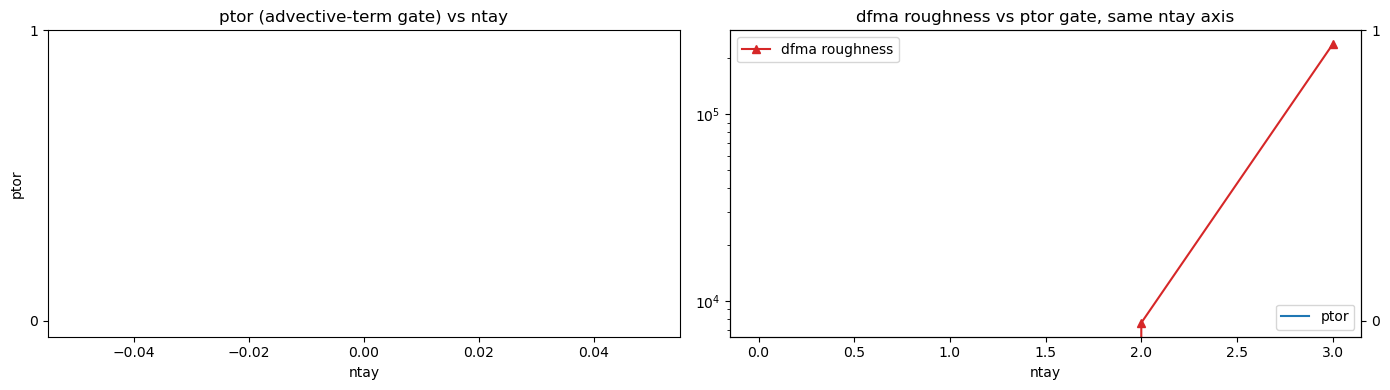

ptor vs ntay (confirms hard on/off gate, no ramp):
 ntay  ptor
  0.0   NaN
  1.0   NaN
  2.0   NaN
  3.0   NaN

dfma roughness vs ntay, for direct comparison:
 ntay  dfma_roughness
  0.0        0.000000
  1.0        0.000000
  2.0     7633.054468
  3.0   236813.571882


In [55]:
ptor_vs_ntay = (cde_sub.groupby('ntay')['ptor']
                .first().reset_index())

fig17, axs17 = plt.subplots(1, 2, figsize=(14, 4))

axs17[0].plot(ptor_vs_ntay.ntay, ptor_vs_ntay.ptor, 'o-')
axs17[0].set_title('ptor (advective-term gate) vs ntay')
axs17[0].set_xlabel('ntay'); axs17[0].set_ylabel('ptor')
axs17[0].set_yticks([0, 1])

axs17[1].plot(rough_dfma.ntay, rough_dfma.dfma_roughness, '^-',
              color='tab:red', label='dfma roughness')
ax17_twin = axs17[1].twinx()
ax17_twin.step(ptor_vs_ntay.ntay, ptor_vs_ntay.ptor, where='post',
               color='tab:blue', label='ptor')
ax17_twin.set_yticks([0, 1])
axs17[1].set_title('dfma roughness vs ptor gate, same ntay axis')
axs17[1].set_xlabel('ntay'); axs17[1].set_yscale('log')
axs17[1].legend(loc='upper left'); ax17_twin.legend(loc='lower right')

plt.tight_layout(); plt.show()

print('ptor vs ntay (confirms hard on/off gate, no ramp):')
print(ptor_vs_ntay.to_string(index=False))
print('\ndfma roughness vs ntay, for direct comparison:')
print(rough_dfma.to_string(index=False))


## `pff_calc` backward F-integration — where does `f(i)` roughness come from?

**Source:** `pff_f_profiles.dat`, dumped by `dina_dump_pff_f` inside
`pff_calc` (`ndop1_new2_400.f`), one row per grid index per call.

Columns: `tt ntay i ai a pff psi fhelp fsqrt f_before_avg ha`.

The dumped quantities are exactly the ingredients of the backward loop
that builds `f(i)` from `pff(i)` and `psi(i)=dψ/da`:

```
f(n) = bt0;  fsqrt = f(n)**2
for i = n..2:  fhelp  = -pff(i) * psi(i) / (2·π·rs0)
                fsqrt  = fsqrt - fhelp * ha(i)
                f(i-1) = sqrt(fsqrt)
```

`f_before_avg` is `f(i)` **before** the face-averaging
`fx(i)=0.5·(f(i)+f(i-1))` that follows in `pff_calc` and would smooth
any high-frequency signal.

**Test logic**: `pfi(i) = 2π·rs0·c3(i)·f(i)`, and cell 34/36 showed that
`c3` is smooth while `pfi` is rough from `ntay=1`. So the roughness must
enter through `f`. Two possibilities:

1. **`pff` (from TOKK) is already knot-jaggy** → the cumulative sum inherits
   it. Upstream culprit is the `pffx→pff` interpolation or TOKK's
   quadratic fit of `c20`.
2. **`pff` is smooth but `fsqrt` picks up noise** → likely from the `psi(i)`
   staircase that CDE hands `pff_calc`, since `fhelp = -pff·psi/(2π·rs0)`.

The cells below overlay `pff`, `psi`, `fhelp`, `fsqrt`, and `f_before_avg`
per `ntay` to distinguish the two.

In [56]:
# Load pff_calc backward F-integration dump
pff_f_cols = ['tt','ntay','i','ai','a','pff','psi','fhelp','fsqrt',
              'f_before_avg','ha']
pff_f = pd.read_csv(path_to_file + 'pff_f_profiles.dat', sep=r'\s+',
                    comment='#', names=pff_f_cols)

print('pff_f_profiles.dat:',
      'ntay range', pff_f.ntay.min(), '->', pff_f.ntay.max(),
      '| tt range', pff_f.tt.min(), '->', pff_f.tt.max(),
      '| n rows:', len(pff_f))

# Distinct ntay values available
print('Distinct ntay (first 15):', sorted(pff_f.ntay.unique())[:15])

pff_f_profiles.dat: ntay range 0 -> 3 | tt range 39000.0 -> 39003.0 | n rows: 1650
Distinct ntay (first 15): [0, 1, 2, 3]


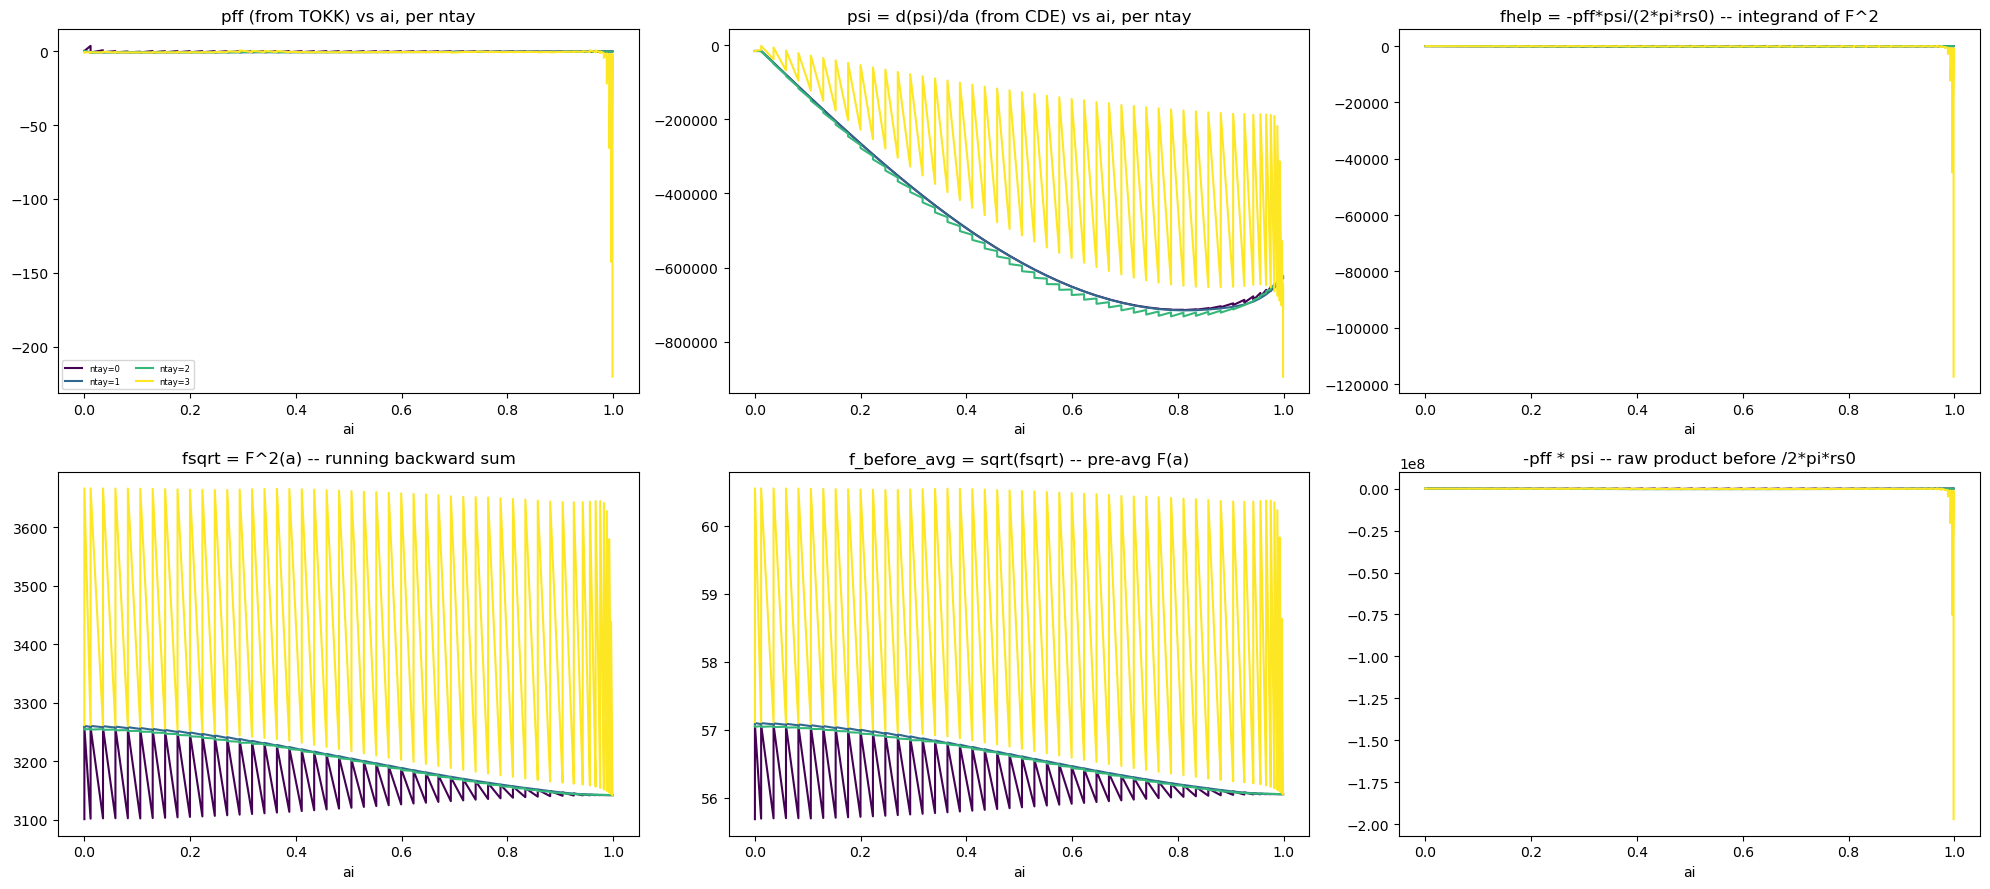

In [57]:
# --- Per-ntay overlay of the whole backward-integration chain.
# Colors run from early ntay (cool) to late ntay (warm) so we can see
# WHERE and WHEN roughness first appears in the pff -> fhelp -> fsqrt -> f
# chain, side-by-side.

pff_f_sub = pff_f[pff_f.ntay <= ntay_max_check].sort_values(['ntay','i'])
ntays_pff = sorted(pff_f_sub.ntay.unique())
norm_pff = plt.Normalize(vmin=min(ntays_pff), vmax=max(ntays_pff))
cmap_pff = plt.cm.viridis

fig_pff, axs_pff = plt.subplots(2, 3, figsize=(20, 9))

for nt in ntays_pff:
    g = pff_f_sub[pff_f_sub.ntay == nt]
    color = cmap_pff(norm_pff(nt))
    axs_pff[0,0].plot(g.ai, g.pff, '-', color=color, label=f'ntay={nt}')
    axs_pff[0,1].plot(g.ai, g.psi, '-', color=color)
    axs_pff[0,2].plot(g.ai, g.fhelp, '-', color=color)
    axs_pff[1,0].plot(g.ai, g.fsqrt, '-', color=color)
    axs_pff[1,1].plot(g.ai, g.f_before_avg, '-', color=color)
    # ratio -pff*psi to see if the integrand carries knot jumps even when
    # each factor individually looks smooth-ish
    axs_pff[1,2].plot(g.ai, -g.pff * g.psi, '-', color=color)

axs_pff[0,0].set_title('pff (from TOKK) vs ai, per ntay')
axs_pff[0,1].set_title('psi = d(psi)/da (from CDE) vs ai, per ntay')
axs_pff[0,2].set_title('fhelp = -pff*psi/(2*pi*rs0) -- integrand of F^2')
axs_pff[1,0].set_title('fsqrt = F^2(a) -- running backward sum')
axs_pff[1,1].set_title('f_before_avg = sqrt(fsqrt) -- pre-avg F(a)')
axs_pff[1,2].set_title('-pff * psi -- raw product before /2*pi*rs0')

for ax in axs_pff.flat:
    ax.set_xlabel('ai')
axs_pff[0,0].legend(fontsize=6, ncol=2)

plt.tight_layout(); plt.show()

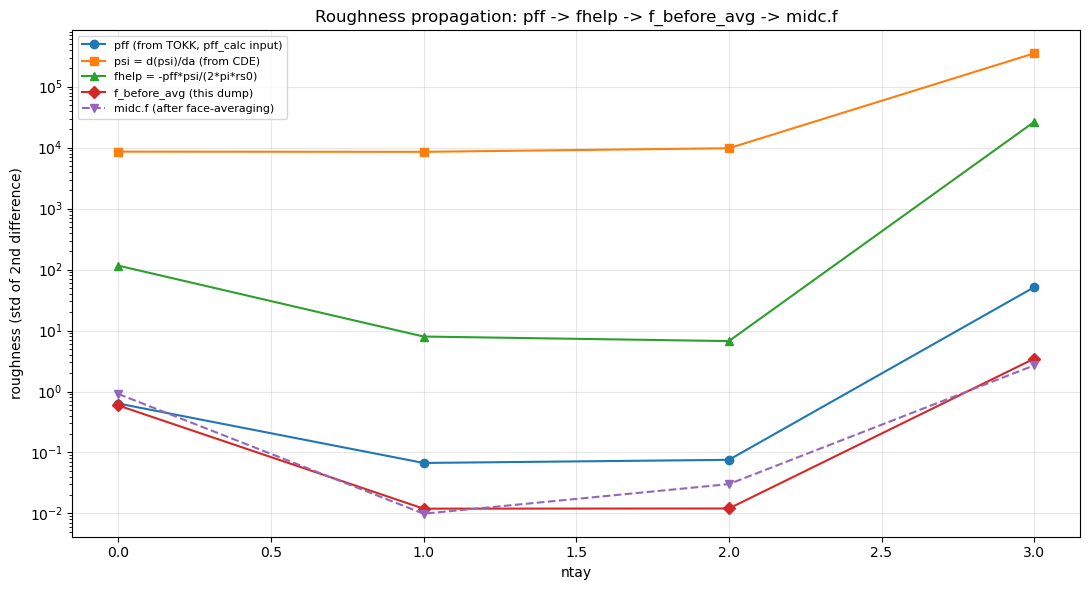

 ntay  pff_roughness  psi_roughness  fhelp_roughness  f_before_avg_roughness  f_roughness
    0       0.635916    8604.812305       116.179439                0.590439     0.911456
    1       0.067330    8544.979014         7.975721                0.011984     0.009905
    2       0.075758    9783.512163         6.716447                0.012057     0.030292
    3      51.410166  352319.149374     26509.323528                3.462382     2.684668


In [58]:
# --- Roughness propagation along the backward-integration chain.
# If pff is smooth but f_before_avg roughens, the source is downstream
# (integration or psi); if pff is already rough, the source is upstream
# (TOKK or the pffx interpolation feeding it).

rough_pff  = roughness(pff_f_sub, 'pff',          group_col='ntay')
rough_psi_pf = roughness(pff_f_sub, 'psi',        group_col='ntay')
rough_fhelp= roughness(pff_f_sub, 'fhelp',        group_col='ntay')
rough_fsq  = roughness(pff_f_sub, 'fsqrt',        group_col='ntay')
rough_fpre = roughness(pff_f_sub, 'f_before_avg', group_col='ntay')

# Compare against the smooth reference (midc.f already loaded, which is
# the *averaged* f -- should be smoother than f_before_avg by construction)
midc_ref = midc.copy()
midc_ref['ntay'] = midc_ref['tt'].map(tt2ntay)
midc_ref = midc_ref[midc_ref.ntay <= ntay_max_check].dropna(subset=['ntay'])
midc_ref['ntay'] = midc_ref['ntay'].astype(int)
rough_f_avg = roughness(midc_ref, 'f', group_col='ntay')

fig_rp, ax_rp = plt.subplots(1, 1, figsize=(11, 6))
ax_rp.plot(rough_pff.ntay,  rough_pff.pff_roughness,          'o-',
           label='pff (from TOKK, pff_calc input)')
ax_rp.plot(rough_psi_pf.ntay, rough_psi_pf.psi_roughness,     's-',
           label='psi = d(psi)/da (from CDE)')
ax_rp.plot(rough_fhelp.ntay,rough_fhelp.fhelp_roughness,      '^-',
           label='fhelp = -pff*psi/(2*pi*rs0)')
ax_rp.plot(rough_fpre.ntay, rough_fpre.f_before_avg_roughness,'D-',
           label='f_before_avg (this dump)')
ax_rp.plot(rough_f_avg.ntay,rough_f_avg.f_roughness,          'v--',
           label='midc.f (after face-averaging)')
ax_rp.set_yscale('log')
ax_rp.set_xlabel('ntay')
ax_rp.set_ylabel('roughness (std of 2nd difference)')
ax_rp.set_title('Roughness propagation: pff -> fhelp -> f_before_avg -> midc.f')
ax_rp.legend(fontsize=8)
ax_rp.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

# Table so the numbers are readable, not just eyeball
table = (rough_pff.merge(rough_psi_pf, on='ntay')
         .merge(rough_fhelp, on='ntay')
         .merge(rough_fpre, on='ntay')
         .merge(rough_f_avg, on='ntay', how='left'))
print(table.to_string(index=False))

/tmp/ipykernel_536697/3004537669.py:16: RuntimeWarning: divide by zero encountered in divide
  np.diff(g_zoom.pff.values) / np.diff(g_zoom.ai.values),


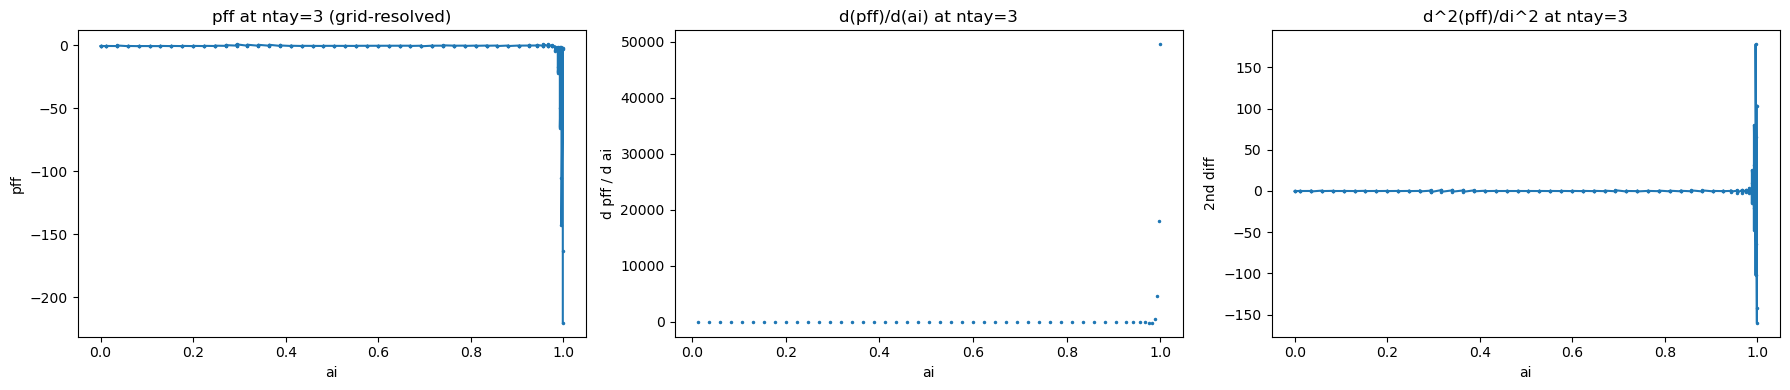

In [59]:
# --- Zoom on one ntay to see if pff jumps at IDS-knot positions.
# If pff has step-like discontinuities at specific ai values, the
# feet_p / linear interpolation table in dina_input2 / pp_pff_mat is
# the source (piecewise-linear interp produces C0-only pffx).

ntay_zoom = min(5, int(pff_f_sub.ntay.max()))   # pick an ntay where roughness is already large
g_zoom = pff_f_sub[pff_f_sub.ntay == ntay_zoom]

fig_z, axs_z = plt.subplots(1, 3, figsize=(18, 4))
axs_z[0].plot(g_zoom.ai, g_zoom.pff, '.-', markersize=3)
axs_z[0].set_title(f'pff at ntay={ntay_zoom} (grid-resolved)')
axs_z[0].set_xlabel('ai'); axs_z[0].set_ylabel('pff')

# Discrete derivative to expose knots
axs_z[1].plot(g_zoom.ai.values[1:],
              np.diff(g_zoom.pff.values) / np.diff(g_zoom.ai.values),
              '.-', markersize=3)
axs_z[1].set_title(f'd(pff)/d(ai) at ntay={ntay_zoom}')
axs_z[1].set_xlabel('ai'); axs_z[1].set_ylabel('d pff / d ai')

# 2nd difference -- spikes here mark knot positions of a C1-discontinuous fit
axs_z[2].plot(g_zoom.ai.values[1:-1],
              np.diff(g_zoom.pff.values, n=2), '.-', markersize=3)
axs_z[2].set_title(f'd^2(pff)/di^2 at ntay={ntay_zoom}')
axs_z[2].set_xlabel('ai'); axs_z[2].set_ylabel('2nd diff')

plt.tight_layout(); plt.show()

## Per-Picard geometry: is the X-point / LCFS moving inside a single ntay?

**Source:** `ptoke1_geom.log`, dumped by `dina_dump_ptoke1_geom` at the
end of every `ptoke1_c` call (i.e. one row per outer-Picard iteration
in `equil2`), from `neq0_sep_lim_32.f`.

Columns: `tt ntay i_bound ksepa psep pmag pbound delaval rsep zsep um vm
jbound bound_len_pol fpl pll tpl fdd fdd0 c2_n c3_n psval_n dm0_n e_sep`.

**Test logic**: at ntay=3 in the VNS crash, `tpl_cal_bc.log` (cell 25)
showed `pll` growing 2.5x and `fpl = pll*tpl/(2*pi)` growing 3x across
4 outer Picard iterations, while `udd = 0` throughout. That growth
must be geometric. Candidates:

- **X-point drift** (`ksepa=1`): `separatrix1` re-detects psep/rsep/zsep
  every ptoke1_c call. If steep VNS edge-current makes the X-point
  position sensitive to small ppx/pffx changes, psep jitters, pbound
  shifts, LCFS moves.
- **Near-separatrix LCFS length divergence**: `pbound = psep + e_sep *
  (pmag - psep)` with `e_sep = 5e-3` puts the LCFS 0.5% inside the
  X-point. For a diverted plasma this surface follows the divertor
  legs -- its poloidal length depends logarithmically on distance from
  the true separatrix. Small psep changes -> large `bound_len_pol`
  changes -> `fpl = (1/N) sum psi_ext(xbound)` grows.
- **Edge metric amplification**: `C2(n)`, `C3(n)` are flux-surface
  averages over the near-separatrix surface; if that surface moves, so
  do these coefficients that then enter the CDE and TOKK.

If in the diverted VNS run any of `psep`, `rsep`, `zsep`, `jbound`,
`bound_len_pol`, or `c2(n)` moves iteration-to-iteration by >>eps2
(the equilibrium tolerance) at ntay=3, the geometric amplifier is
confirmed.

In [ ]:
# Load per-Picard geometry log
# The Fortran dump now uses list-directed I/O (write(88,*) ...) with an
# explicit recl=2048, so no format-width can shift columns. If loading
# still shows misalignment, compare the first data line against
# geom_cols below.
import os

geom_cols = ['tt','ntay','i_bound','ksepa','psep','pmag','pbound',
             'delaval','rsep','zsep','um','vm','jbound',
             'bound_len_pol','fpl','pll','tpl','fdd','fdd0',
             'c2_n','c3_n','psval_n','dm0_n','e_sep',
             'al1','errm','tok_plus_tokg','it1']

log_path = os.path.expanduser(path_to_file + 'ptoke1_geom.log')

# --- Header + first data line sanity check ---
with open(log_path, 'r') as fh:
    first_lines = [next(fh).rstrip('\n') for _ in range(3)]
print('First 3 lines of ptoke1_geom.log:')
for k, L in enumerate(first_lines):
    print(f'  [{k}] ({len(L)} chars) {L[:200]}{" ..." if len(L)>200 else ""}')
# Count tokens on the first data line (index 1, since line 0 is header)
first_data = first_lines[1] if not first_lines[0].startswith('#') else first_lines[1]
n_tokens = len(first_data.split())
print(f'First data line has {n_tokens} whitespace-separated tokens '
      f'(expected {len(geom_cols)}).')

geom = pd.read_csv(log_path, sep=r'\s+',
                   comment='#', names=geom_cols)

print()
print('ptoke1_geom.log parsed:')
print('  ntay range', geom.ntay.min(), '->', geom.ntay.max(),
      '| i_bound range', geom.i_bound.min(), '->', geom.i_bound.max(),
      '| n rows:', len(geom))
print('  Distinct ntay (first 15):', sorted(geom.ntay.unique())[:15])
print('  Distinct ksepa values:', sorted(geom.ksepa.unique()))
print('  e_sep (should be constant):', geom.e_sep.unique())
try:
    print('  it1 distribution (0=converged, 1=not):',
          geom['it1'].value_counts().to_dict())
except KeyError:
    print('  (it1 column missing -- column count mismatch)')


In [61]:
# --- Overview table: for each ntay, how many ptoke1 iterations and
# how much do the geometric quantities move iteration-to-iteration?

# Pick the highest ntay so we look at the crash-adjacent step.
ntay_focus = int(geom.ntay.max())
g_focus = geom[geom.ntay == ntay_focus].sort_values('i_bound').copy()

print(f'--- ntay={ntay_focus}: full per-Picard trace ---')
show_cols = ['i_bound','ksepa','psep','rsep','zsep','pbound',
             'jbound','bound_len_pol','fpl','pll','tpl',
             'c2_n','c3_n']
print(g_focus[show_cols].to_string(index=False))

# Relative iter-to-iter change on the amplifier candidates
print(f'\n--- ntay={ntay_focus}: relative iter-to-iter changes ---')
for col in ['psep','rsep','zsep','pbound','bound_len_pol',
            'fpl','pll','tpl','c2_n','c3_n']:
    s = g_focus[col].values
    if len(s) < 2 or np.all(s == 0):
        continue
    rel = np.diff(s) / np.where(np.abs(s[:-1])>1e-30, np.abs(s[:-1]), 1)
    print(f'  {col:>18s}: max |Δrel| = {np.max(np.abs(rel)):.3e}  '
          f'(range {s.min():.4g} -> {s.max():.4g})')

--- ntay=261758: full per-Picard trace ---
Empty DataFrame
Columns: [i_bound, ksepa, psep, rsep, zsep, pbound, jbound, bound_len_pol, fpl, pll, tpl, c2_n, c3_n]
Index: []

--- ntay=261758: relative iter-to-iter changes ---


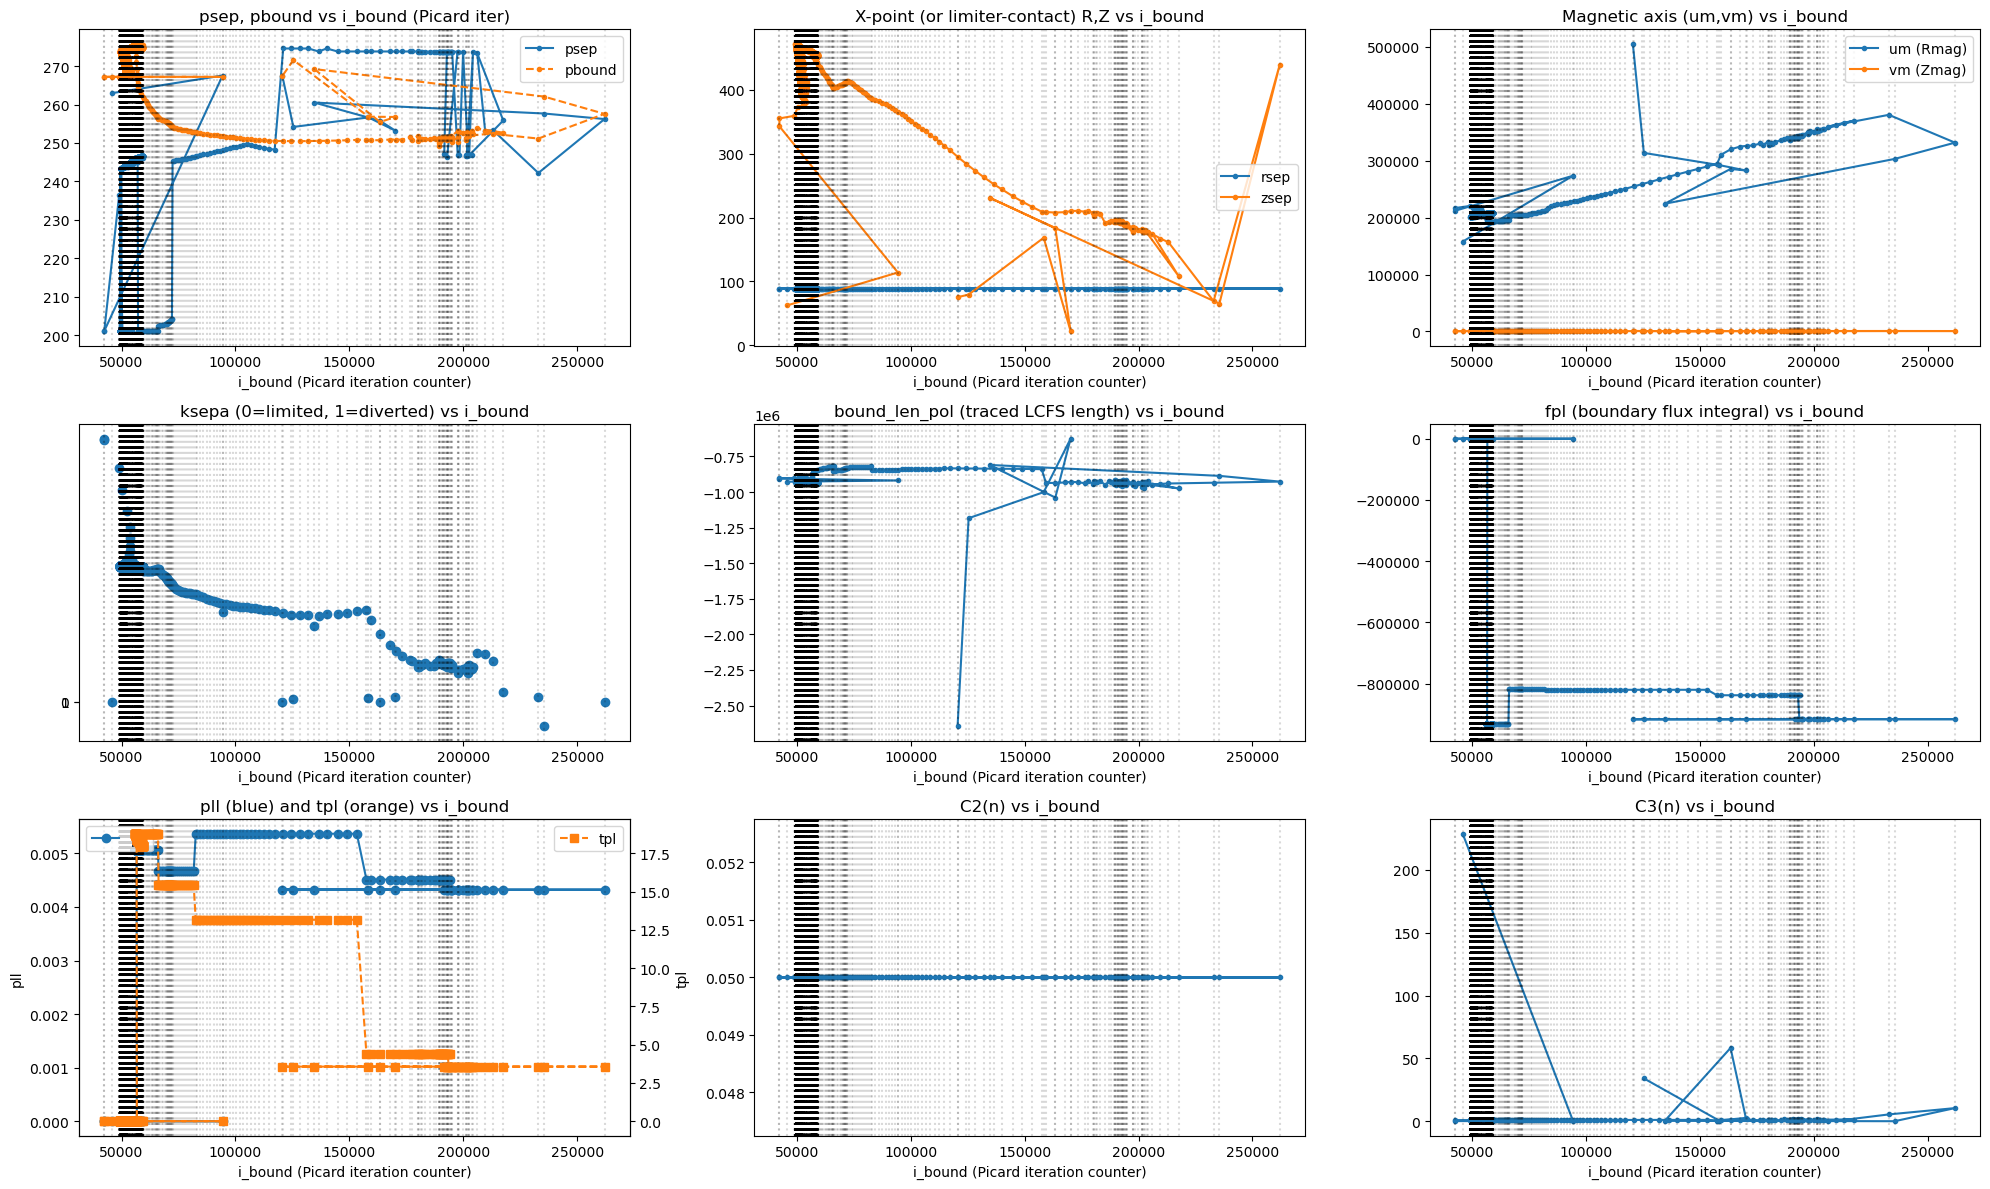

In [ ]:
# --- Visualize the geometric-amplifier candidates across ALL ntay,
# with i_bound as the x-axis so we see per-Picard-iteration behavior.

fig_g, axs_g = plt.subplots(3, 3, figsize=(20, 12))

# psep, pbound (flux value at LCFS)
axs_g[0,0].plot(geom.i_bound, geom.psep, '.-', label='psep')
axs_g[0,0].plot(geom.i_bound, geom.pbound, '.--', label='pbound')
axs_g[0,0].set_title('psep, pbound vs i_bound (Picard iter)')
axs_g[0,0].legend()

# rsep, zsep (X-point / limiter-contact position)
axs_g[0,1].plot(geom.i_bound, geom.rsep, '.-', label='rsep')
axs_g[0,1].plot(geom.i_bound, geom.zsep, '.-', label='zsep')
axs_g[0,1].set_title('X-point (or limiter-contact) R,Z vs i_bound')
axs_g[0,1].legend()

# um, vm (magnetic axis)
axs_g[0,2].plot(geom.i_bound, geom.um, '.-', label='um (Rmag)')
axs_g[0,2].plot(geom.i_bound, geom.vm, '.-', label='vm (Zmag)')
axs_g[0,2].set_title('Magnetic axis (um,vm) vs i_bound')
axs_g[0,2].legend()

# ksepa (limited=0 / diverted=1)
axs_g[1,0].scatter(geom.i_bound, geom.ksepa)
axs_g[1,0].set_title('ksepa (0=limited, 1=diverted) vs i_bound')
axs_g[1,0].set_yticks([0,1])

# LCFS length (poloidal)
axs_g[1,1].plot(geom.i_bound, geom.bound_len_pol, '.-')
axs_g[1,1].set_title('bound_len_pol (traced LCFS length) vs i_bound')

# fpl
axs_g[1,2].plot(geom.i_bound, geom.fpl, '.-')
axs_g[1,2].set_title('fpl (boundary flux integral) vs i_bound')

# pll and tpl
ax_pt = axs_g[2,0]
ax_pt.plot(geom.i_bound, geom.pll, 'o-', label='pll')
ax_pt.set_ylabel('pll'); ax_pt.legend(loc='upper left')
ax_pt_t = ax_pt.twinx()
ax_pt_t.plot(geom.i_bound, geom.tpl, 's--', color='tab:orange', label='tpl')
ax_pt_t.set_ylabel('tpl'); ax_pt_t.legend(loc='upper right')
ax_pt.set_title('pll (blue) and tpl (orange) vs i_bound')

# edge metric C2(n)
axs_g[2,1].plot(geom.i_bound, geom.c2_n, '.-')
axs_g[2,1].set_title('C2(n) vs i_bound')

# edge metric C3(n)
axs_g[2,2].plot(geom.i_bound, geom.c3_n, '.-')
axs_g[2,2].set_title('C3(n) vs i_bound')

# Add ntay-transition vertical lines
ntay_starts = (geom.groupby('ntay').i_bound.min().reset_index()
                .sort_values('ntay'))
for ax in axs_g.flat:
    for _, row in ntay_starts.iterrows():
        ax.axvline(row.i_bound, color='k', alpha=0.15, linestyle=':')
    ax.set_xlabel('i_bound (Picard iteration counter)')


plt.tight_layout(); plt.show()

In [63]:
# --- Direct test of the divertor-amplifier hypothesis at the crash ntay:
# compare within-ntay spread of geometric quantities against between-ntay
# stable trend. If within-ntay spread at crash ntay is much larger than
# earlier ntays, the free-boundary iteration is oscillating instead of
# converging.

def within_ntay_spread(df, col):
    return (df.groupby('ntay')[col]
            .agg(['min','max','mean','std','count'])
            .assign(rel_spread=lambda d: (d['max']-d['min'])
                    /(d['mean'].abs()+1e-30)))

for col in ['psep','pbound','rsep','zsep','bound_len_pol','fpl',
            'pll','tpl','c2_n','c3_n']:
    print(f'\n{col}:')
    print(within_ntay_spread(geom, col).to_string())


psep:
                  min        max        mean        std  count    rel_spread
ntay                                                                        
45936.528   262.97900  262.97900  262.979000        NaN      1  0.000000e+00
120590.620  267.44375  267.44375  267.443750        NaN      1  0.000000e+00
126852.880  254.17402  254.17402  254.174020        NaN      1  0.000000e+00
128442.250  201.00000  201.00000  201.000000        NaN      1  0.000000e+00
128442.560  201.00000  201.00000  201.000000        NaN      1  0.000000e+00
128442.900  201.00000  201.00000  201.000000        NaN      1  0.000000e+00
128443.260  201.00000  201.00000  201.000000        NaN      1  0.000000e+00
128443.640  201.00000  201.00000  201.000000        NaN      1  0.000000e+00
128444.060  201.00000  201.00000  201.000000        NaN      1  0.000000e+00
128444.510  201.00000  201.00000  201.000000        NaN      1  0.000000e+00
128444.990  201.00000  201.00000  201.000000        NaN      1  0.000